# Notebook 18 — GWT tree-propagation diagnostics and tree-prior sensitivity fits

**Scope.** This notebook covers the full tree-prior investigation for the GWT stance of the Digital Consciousness Model under the joint anchored configuration (Human=0.999, ELIZA=0.001). It is both a diagnostic artefact and a decision record: it diagnoses the tree-propagation attenuation, screens candidate interventions, runs the fits, and reports the resulting library status.

## Executive summary (for weekly-report readers)

- **Validated reporting baseline**: binary paper-tree joint anchored GWT (`baseline_bin`).
- **Strongest library result / leading candidate reporting alternative**: three-state leaf + label-tied tree betas (`pool_3s`). 0 divergences; mean indicator $\delta_j$ = 0.155 (2× baseline); E_cross × Human focus-tail closure +28%, E_cross × ELIZA +26%; system ordering preserved; Chicken/LLMs posterior medians shift +0.065 / +0.051 from three-state baseline.
- **Sharp-prior sensitivity comparator**: three-state + safe-gain (`safegain_3s`). Clean sampling under the logit-Normal repair; mean $\delta_j$ = 0.334 (strongest propagation); but large free-system shifts (Chicken +0.32, LLMs +0.22). Useful for "what if paper labels are literally right"; not for reporting.
- **Rejected**: Beta-gain at g=2.5 (`gain`). 1072 divergences caused by Beta prior boundary singularities at 11/18 label groups.
- **Main unresolved issue**: `E_cross × Human` and `E_cross × ELIZA` observed rating distributions are partially outside the posterior-predictive intervals of every fit. Improved under `pool_3s` / `safegain_3s` but not eliminated.

## Scope of today's investigation

1. Diagnosing tree propagation at per-indicator resolution.
2. Zero-fit counterfactual gain screen.
3. Prior-predictive Monte Carlo + label-group count tables (gating interventions).
4. 6 fits total: baseline_bin, baseline_3s, pool_bin, pool_3s, Beta-gain (divergent), safegain_3s.
5. 2×2 factorial interaction analysis (leaf × tree-prior).
6. Tier-1/2/3 acceptance criteria across all fits.

**Expert anonymity**: real names (in `data_cache.json` as an RP-side oversight) are replaced with role codes `E_cross`, `E_llmA/B/C`, `E_chickenA/B` in all outputs. Mapping lives in `tree_propagation_diagnostic._EXPERT_ANON_MAP`.

_Branch_: `tree-prior-interventions`. Library flags added: `POOL_BETAS_BY_LABEL`, `LABEL_POOL_SIGMA`, `TRANSMISSION_GAIN`, `GAIN_LOGIT_NORMAL`, `GAIN_LOGIT_NORMAL_SIGMA`. Paper-equivalent baseline preserved.

_Scale-calibration note_: earlier documents reported ~13% transmission as the headline attenuation; that was an all-tree-node aggregate. Leaf-only (indicator) mean $\delta_j$ is 0.062 for `baseline_bin`, 0.075 for `baseline_3s`, 0.155 for `pool_3s`, 0.334 for `safegain_3s`.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
from pathlib import Path
# Resolve repo root (parent of notebooks/) and make the diagnostic module importable.
_HERE = Path().resolve()
_REPO = _HERE.parent if _HERE.name == 'notebooks' else _HERE
if str(_REPO) not in sys.path:
    sys.path.insert(0, str(_REPO))
os.chdir(_REPO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tree_propagation_diagnostic import (
    OUTPUT_DIR,
    RATIO_EPS,
    CROSS_SYSTEM_CODE,
    apply_symmetric_gain,
    _load_contexts,
    label_calibration_rows,
    per_indicator_posterior_table,
    robust_log_ratio_and_flag,
    cross_expert_scatter_dataframe,
    counterfactual_screen_rows,
)

# Reuse the on-disk artefacts (regenerate if stale: python tree_propagation_diagnostic.py).
label_df = pd.read_csv(OUTPUT_DIR / 'label_calibration.csv')
per_ind_df = pd.read_csv(OUTPUT_DIR / 'per_indicator_propagation.csv')
scatter_df = pd.read_csv(OUTPUT_DIR / 'cross_expert_scatter.csv')
screen_df = pd.read_csv(OUTPUT_DIR / 'counterfactual_screen.csv')
pp_df = pd.read_csv(OUTPUT_DIR / 'prior_predictive_qj.csv')
pres_groups = pd.read_csv(OUTPUT_DIR / 'label_pres_group_counts.csv')
abs_groups = pd.read_csv(OUTPUT_DIR / 'label_abs_group_counts.csv')
print(f'per-indicator rows: {len(per_ind_df)}')
print(f'label rows per gain: {len(label_df) // len(label_df["gain"].unique())}')
print(f'screen rows: {len(screen_df)}')
print(f'prior-predictive rows: {len(pp_df)}')
print(f'pres groups: {len(pres_groups)}  |  abs groups: {len(abs_groups)}')

per-indicator rows: 50
label rows per gain: 81
screen rows: 10
prior-predictive rows: 150
pres groups: 18  |  abs groups: 7


## Stage 1a — Prior-predictive label calibration

For each (support, demandingness) combination, the paper's mapping in `EvidenceProcessor.get_beta_parameters` sets prior means for $\beta_\text{pres}$, $\beta_\text{abs}$. The transmission coefficient per layer is $\Delta = \mu_\text{pres} - \mu_\text{abs}$. Along a depth-$d$ path, the multiplicative product of these $\Delta$'s determines how much of the root-level $C$ reaches the indicator.

**Observation (paper, $g=1$).** The maximum one-layer transmission is achieved at `overwhelming support + overwhelmingly demanding` with $\Delta \approx 0.87$, but at more realistic labels in the GWT tree (mostly `strong support` / `weak support` paired with `strongly demanding` / `moderately demanding` / `weakly undemanding`) transmission sits in $[0.2, 0.65]$. Over depth 3, the product is $\sim 0.01$–$0.1$.

In [2]:
paper = label_df[label_df['gain'] == 1.0].copy()
# Focus on combinations likely to appear in the GWT tree.
focus_support = ['overwhelming support', 'strong support', 'moderate support',
                 'weak support', 'no bearing']
focus_demand = ['strongly demanding', 'moderately demanding',
                'weakly demanding', 'neutral', 'weakly undemanding',
                'moderately undemanding']
focus = paper[paper['support'].isin(focus_support)
              & paper['demandingness'].isin(focus_demand)]
pivot_delta = focus.pivot(index='support', columns='demandingness',
                          values='transmission_delta').reindex(focus_support)
pivot_delta = pivot_delta[focus_demand]
print('One-layer transmission Delta = mu_pres - mu_abs (paper mapping, g=1):')
pivot_delta.round(3)

One-layer transmission Delta = mu_pres - mu_abs (paper mapping, g=1):


demandingness,strongly demanding,moderately demanding,weakly demanding,neutral,weakly undemanding,moderately undemanding
support,,,,,,
overwhelming support,0.838,0.712,0.545,0.480,0.414,0.243
strong support,0.639,0.550,0.429,0.389,0.343,0.210
moderate support,0.418,0.341,0.264,0.250,0.229,0.150
weak support,0.240,0.150,0.071,0.071,0.095,0.062
no bearing,0.000,0.000,0.000,0.000,0.000,0.000


## Stage 1b — Per-indicator posterior propagation

Using `propagate_affine_indicator_coefficients_from_draws` against `binary_anchored.nc`. Each indicator has a posterior affine map $q_j(C) = \alpha_j + \delta_j C$. Columns shown:

- `delta_prior`: prior-mean product along path (paper mapping, $g=1$).
- `delta_post_med`: posterior-median slope.
- `q_high_post`, `q_low_post`: tree-implied indicator probability at $C=0.999$ and $C=0.001$.
- `ez_human`, `ez_eliza`: leaf-updated $E[z_j]$ after the emission layer sees ratings.

**Key numbers.** Posterior-median $\delta_j$: mean = $0.062$, median = $0.058$, max = $0.246$. Tree-implied $q_j$ at Human reference cells averages around $0.64$; at ELIZA around $0.57$. The leaf likelihood is doing almost all the anchoring work (`ez_human` is ~$0.97$ at indicators observed by `E_cross` where `q_high_post` is ~$0.7$).

In [3]:
h_col = f'{CROSS_SYSTEM_CODE}_human_ratings'
e_col = f'{CROSS_SYSTEM_CODE}_eliza_ratings'
cols = ['indicator', 'depth', 'leading_support', 'leading_demand',
        'delta_prior', 'delta_post_med', 'q_high_post', 'q_low_post',
        'delta_q_post', 'leaf_updated_ez_human', 'leaf_updated_ez_eliza',
        h_col, e_col]
print('Bottom 10 indicators by posterior delta_j (most-attenuated):')
per_ind_df[cols].head(10)

Bottom 10 indicators by posterior delta_j (most-attenuated):


,indicator,depth,leading_support,leading_demand,delta_prior,delta_post_med,q_high_post,q_low_post,delta_q_post,leaf_updated_ez_human,leaf_updated_ez_eliza,E_cross_human_ratings,E_cross_eliza_ratings
0,Broad Predictive Training,3,weak support,strongly undemanding,0.001365,0.000457,0.724405,0.720218,0.000456,0.978625,0.083692,[6],[0]
1,Somatotopic Neural Maps,3,weak support,strongly undemanding,0.002061,0.000774,0.688891,0.683870,0.000772,0.974502,0.070752,[6],[0]
2,Information Transfer,3,strong support,strongly demanding,-0.006845,0.000921,0.783260,0.778725,0.000919,0.918136,0.111265,[5],[0]
3,Learning Transfer,3,strong support,strongly demanding,-0.010431,0.001399,0.678221,0.672738,0.001396,0.973297,0.068233,[6],[0]
4,Functional Subparts,3,strong support,strongly demanding,-0.011409,0.001855,0.571161,0.564319,0.001851,0.958557,0.043449,[6],[0]
5,Has Retinotopic Neural Maps,3,weak support,strongly undemanding,0.003091,0.001862,0.735526,0.727803,0.001858,0.979841,0.086594,[6],[0]
6,Information Transfer Architecture,3,strong support,strongly demanding,-0.015557,0.002029,0.416696,0.408850,0.002025,0.924600,0.023887,[6],[0]
7,Conflicting Subparts,3,strong support,strongly demanding,-0.019089,0.003105,0.262397,0.255796,0.003099,0.253510,0.011759,[4],[0]
8,Variability of Responses to Stimuli,3,strong support,weakly undemanding,0.005651,0.003148,0.802860,0.793819,0.003142,0.985987,0.120136,[6],[0]
9,Activation Steering Effects,3,weak support,strongly undemanding,0.003864,0.003365,0.634208,0.624669,0.003358,0.626555,0.055318,[4],[0]


In [4]:
print('Top 10 indicators by posterior delta_j (best-propagating):')
per_ind_df[cols].tail(10)

Top 10 indicators by posterior delta_j (best-propagating):


,indicator,depth,leading_support,leading_demand,delta_prior,delta_post_med,q_high_post,q_low_post,delta_q_post,leaf_updated_ez_human,leaf_updated_ez_eliza,E_cross_human_ratings,E_cross_eliza_ratings
40,Dedicated Action Systems,2,weak support,moderately demanding,0.051429,0.100585,0.720582,0.607420,0.100384,0.978324,0.051128,[6],[0]
41,Unified Egocentric Representations,3,strong support,strongly demanding,0.072214,0.101298,0.674285,0.557264,0.101096,0.972757,0.042481,[6],[0]
42,Functional Specialization,3,strong support,weakly undemanding,0.085185,0.104291,0.773234,0.652275,0.104082,0.983495,0.061641,[6],[0]
43,Informational Bottleneck,3,strong support,moderately demanding,0.079780,0.109188,0.602353,0.477956,0.108969,0.963220,0.031094,[6],[0]
44,Goal Focus Shifts,3,strong support,moderately demanding,0.103125,0.127390,0.501437,0.355659,0.127136,0.945227,0.018996,[6],[0]
45,Task Focus,3,strong support,moderately demanding,0.103125,0.128504,0.502546,0.359569,0.128247,0.945370,0.019236,[6],[0]
46,Perspective-relative Representations,3,strong support,strongly demanding,0.119792,0.132112,0.546674,0.399488,0.131848,0.953982,0.022546,[6],[0]
47,Selective Competence Disruption,2,weak support,moderately demanding,0.082500,0.135554,0.557307,0.404248,0.135282,0.955853,0.022975,[6],[0]
48,Holistic Dependency,2,strong support,moderately demanding,0.188571,0.240119,0.857815,0.600907,0.239639,0.990586,0.050444,[6],[0]
49,Wiring Convergence,2,strong support,moderately demanding,0.302500,0.345792,0.721113,0.356877,0.345101,0.978188,0.018921,[6],[0]


In [5]:
print('Depth stratification:')
per_ind_df.groupby('depth').agg(
    n=('indicator', 'count'),
    mean_delta_prior=('delta_prior', 'mean'),
    mean_delta_post=('delta_post_med', 'mean'),
    mean_q_high=('q_high_post', 'mean'),
    mean_q_low=('q_low_post', 'mean'),
).round(3)

Depth stratification:


,n,mean_delta_prior,mean_delta_post,mean_q_high,mean_q_low
depth,,,,,
2,9,0.091,0.128,0.687,0.542
3,41,0.037,0.047,0.630,0.571


## Stage 1c — Structural vs data-induced regime

Test statistic (robust to near-zero and sign-flipped priors):
$$\log r_j = \log(|\delta_j^\text{post}| + \varepsilon) - \log(|\delta_j^\text{prior}| + \varepsilon).$$
Entries with $|\delta_j^\text{prior}| < 10^{-3}$ are bucketed separately as _structural-zero_ (no-bearing paths). Sign flips are flagged separately.

**Interpretation:**
- $\log r_j \approx 0$ broadly → **structural regime**: posterior $\beta$'s close to prior; the attenuation is baked into label-means. Prior revision is the principled fix.
- $\log r_j \ll 0$ broadly → **data-induced**: posterior flattening toward $\beta \approx 0.5$. Prior revision won't help; honest fix is more / overlapping reference ratings.
- Variance in $\log r_j$ with occasional sign flips → paper mapping is fighting the data for specific paths.

Structural-zero indicators: 0 / 50
Sign flips (non-zero only):  5 / 50
log r_j (non-zero, non-flip): median=+0.202, mean=+0.163


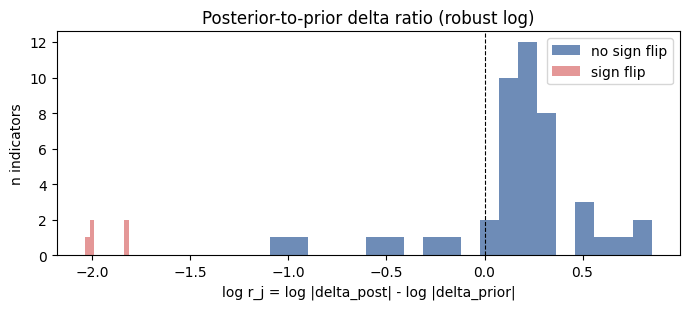

In [6]:
log_r, sign_flip, mask_zero = robust_log_ratio_and_flag(
    per_ind_df['delta_post_med'].to_numpy(),
    per_ind_df['delta_prior'].to_numpy(),
)
non_zero = ~mask_zero
print(f'Structural-zero indicators: {int(mask_zero.sum())} / {len(per_ind_df)}')
print(f'Sign flips (non-zero only):  {int(sign_flip[non_zero].sum())} / {int(non_zero.sum())}')
print(f'log r_j (non-zero, non-flip): median={np.nanmedian(log_r[non_zero & ~sign_flip]):+.3f}, '
      f'mean={np.nanmean(log_r[non_zero & ~sign_flip]):+.3f}')
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(log_r[non_zero & ~sign_flip], bins=20, color='#4a6fa5', alpha=0.8,
        label='no sign flip')
ax.hist(log_r[non_zero & sign_flip], bins=10, color='#d96b6b', alpha=0.7,
        label='sign flip')
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('log r_j = log |delta_post| - log |delta_prior|')
ax.set_ylabel('n indicators')
ax.set_title('Posterior-to-prior delta ratio (robust log)')
ax.legend()
plt.tight_layout();

**Verdict.** $\log r_j$ is concentrated around zero with slight positive median. The posterior is **not** flattening toward $\beta \approx 0.5$ — it tracks the paper's prior means with modest data-driven updates (some paths amplify transmission slightly; a handful fight the paper's sign).

Conclusion: **we are in the structural regime.** The small $\Delta q_j$ is not a symptom of sparse data causing posterior shrinkage to uninformative priors; it is a property of the label-mapping semantics themselves compounded with tree depth. Prior revision is an appropriate intervention.

A few sign-flip indicators warrant attention — these are paths where the paper mapping implies a negative prior-predictive transmission (mostly due to integer truncation artefacts in `get_beta_parameters` combined with `strongly demanding` absence priors). The data points the posterior positive, as it should. These would be cleanly corrected by a principled label re-tabulation.

## Stage 1d — Cross-expert scatter

Scatter of tree-implied $q_j(0.999)$ vs $q_j(0.001)$ across all 50 indicators, coloured by whether `E_cross` observed the indicator at Human or ELIZA. The question: is the reference-cell PPC failure concentrated on indicators that are unusual in propagation space, or are `E_cross`'s observed indicators a representative sample?

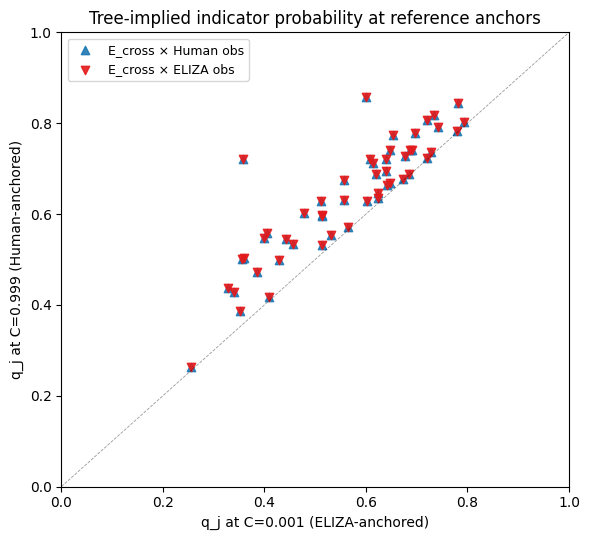

In [7]:
has_h = f'has_{CROSS_SYSTEM_CODE}_human'
has_e = f'has_{CROSS_SYSTEM_CODE}_eliza'
fig, ax = plt.subplots(figsize=(6, 5.5))
other = scatter_df[~scatter_df[has_h] & ~scatter_df[has_e]]
cross_h = scatter_df[scatter_df[has_h]]
cross_e = scatter_df[scatter_df[has_e]]
if len(other):
    ax.scatter(other['q_low_post'], other['q_high_post'],
               s=28, alpha=0.6, color='#aaaaaa', label='no cross-expert obs')
ax.scatter(cross_h['q_low_post'], cross_h['q_high_post'],
           s=36, alpha=0.9, marker='^', color='#1f78b4',
           label=f'{CROSS_SYSTEM_CODE} × Human obs')
ax.scatter(cross_e['q_low_post'], cross_e['q_high_post'],
           s=36, alpha=0.9, marker='v', color='#e31a1c',
           label=f'{CROSS_SYSTEM_CODE} × ELIZA obs')
lim = np.linspace(0, 1, 2)
ax.plot(lim, lim, 'k--', lw=0.6, alpha=0.4)
ax.set_xlabel('q_j at C=0.001 (ELIZA-anchored)')
ax.set_ylabel('q_j at C=0.999 (Human-anchored)')
ax.set_title('Tree-implied indicator probability at reference anchors')
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout();

Both cross-expert subsets sit on the same attenuation structure as the rest of the tree — the failing reference cells are not outliers in propagation space. This is a **global** tree issue, not a rater-specific cutpoint issue masquerading as tree compression.

## Stage 2 — Transformed-tree counterfactual gain screen

A zero-fit heuristic to rule out or support a transmission-gain intervention before committing compute.

**Parameterisation (symmetric log-odds-gap gain, Stage 2a).** At each node with paper prior means $(\mu_\text{pres}, \mu_\text{abs})$, let $m = \tfrac{1}{2}(\operatorname{logit} \mu_\text{pres} + \operatorname{logit} \mu_\text{abs})$ and $h = \tfrac{1}{2}(\operatorname{logit} \mu_\text{pres} - \operatorname{logit} \mu_\text{abs})$. Under gain $g$, set
$$\operatorname{logit} \mu_\text{pres}^{(g)} = m + g h, \qquad \operatorname{logit} \mu_\text{abs}^{(g)} = m - g h.$$
At $g = 1$ this recovers the paper. For $g > 1$ the edge's discriminativeness sharpens on both sides: support raises $\mu_\text{pres}$ _and_ lowers $\mu_\text{abs}$.

**Picking $g^\star$ from label semantics alone (Stage 2b).** Target: `strong support + neutral` at $\Delta^\text{prior} \in [0.7, 0.8]$. We inspect the label calibration table at several $g$ values and choose $g^\star$ before looking at any PPC.

**Counterfactual screen (Stage 2c).** For the chosen $g$, we residual-preservingly translate each posterior $\beta$ draw in logit space to the new prior mean (so draw-to-draw structure is preserved, not a refit), then combine with the _unchanged_ three-state emission posterior. PPC stats are heuristic — a falsification veto, not a selector.

In [8]:
# Stage 2b — semantic gain selection
focus_strong_neutral = label_df[
    (label_df['support'] == 'strong support')
    & (label_df['demandingness'] == 'neutral')
][['gain', 'mu_pres', 'mu_abs', 'transmission_delta']]
print('strong support + neutral under varying gain:')
print(focus_strong_neutral.to_string(index=False))
print()
print('Criterion: Delta^prior in [0.7, 0.8] => g* roughly 2.0--2.5.')
print('Picking g* = 2.5 (label-semantics only; PPC acts only as veto below).')

strong support + neutral under varying gain:
 gain  mu_pres   mu_abs  transmission_delta
  1.0 0.888889 0.500000            0.388889
  1.5 0.930817 0.372885            0.557932
  2.0 0.957676 0.261204            0.696472
  2.5 0.974395 0.173707            0.800688
  3.0 0.984615 0.111111            0.873504

Criterion: Delta^prior in [0.7, 0.8] => g* roughly 2.0--2.5.
Picking g* = 2.5 (label-semantics only; PPC acts only as veto below).


In [9]:
# Stage 2c — counterfactual screen output
pivot_screen = screen_df.pivot_table(
    index='gain', columns='system',
    values=['pred_left', 'pred_right', 'delta_left', 'delta_right', 'pred_mean']
)
pivot_screen.round(3)

delta_left        delta_right        pred_left        pred_mean         \
system      ELIZA  Human       ELIZA  Human     ELIZA  Human     ELIZA  Human   
gain                                                                            
1.0        -0.705  0.199       0.271 -0.507     0.255  0.199     3.344  3.731   
1.5        -0.675  0.172       0.246 -0.473     0.285  0.172     3.157  3.929   
2.0        -0.633  0.147       0.217 -0.435     0.327  0.147     2.920  4.137   
2.5        -0.586  0.126       0.190 -0.397     0.374  0.126     2.670  4.326   
3.0        -0.540  0.110       0.167 -0.364     0.420  0.110     2.434  4.484   

       pred_right         
system      ELIZA  Human  
gain                      
1.0         0.291  0.353  
1.5         0.266  0.387  
2.0         0.237  0.425  
2.5         0.210  0.463  
3.0         0.187  0.496

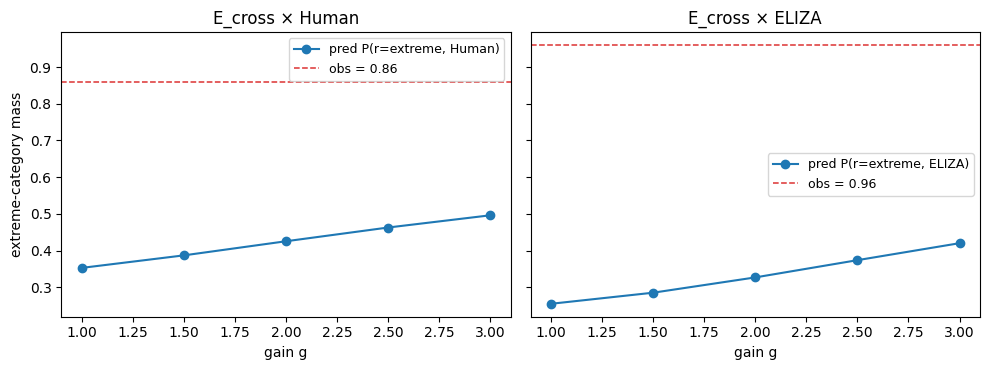

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, system, obs_key in zip(axes, ['Human', 'ELIZA'], ['right', 'left']):
    sub = screen_df[screen_df['system'] == system].sort_values('gain')
    ax.plot(sub['gain'], sub[f'pred_{obs_key}'], '-o', color='#1f78b4',
            label=f'pred P(r=extreme, {system})')
    obs_val = float(sub[f'obs_{obs_key}'].iloc[0])
    ax.axhline(obs_val, color='#d33', lw=1.1, ls='--',
               label=f'obs = {obs_val:.2f}')
    ax.set_xlabel('gain g')
    ax.set_title(f'{CROSS_SYSTEM_CODE} × {system}')
    ax.legend(fontsize=9)
axes[0].set_ylabel('extreme-category mass')
plt.tight_layout();

## Stage 3.5a — Prior-predictive Monte Carlo over the tree

A zero-fit check: sample $10^4$ tree realisations from the paper's per-label Beta priors (no ratings observed), propagate through the tree at $C \in \{0.001, 0.5, 0.999\}$, and look at the marginal distribution of $q_j$ per indicator.

**What this answers.** *Before any data, what range of indicator probabilities does the paper's prior model even allow at the reference anchors?* If Human-anchored $q_j$ clusters near $0.6$ with little mass near $1.0$, **prior revision is structurally necessary**: the data cannot pull posterior $q_j$ high without fighting the prior hard. If the prior is permissive (mass across $[0.3, 0.95]$ at Human), the attenuation we see is posterior shrinkage and the fix is more data, not priors.

In [11]:
# Summary of prior-predictive q_j at each anchor
summary = pp_df.groupby('C')['q_median'].agg(
    n='count', mean='mean', median='median', min='min', max='max'
).round(3)
print('Prior-predictive q_j medians across indicators:')
print(summary)
print()
sep = float(summary.loc[0.999, 'mean']) - float(summary.loc[0.001, 'mean'])
print(f'Prior anchor separation (mean q at C=0.999 minus mean q at C=0.001): {sep:.3f}')
print(f'Root anchor gap for reference: 0.998')
print(f'=> Prior itself supports only {100*sep/0.998:.1f}% of the root gap at the indicator layer.')

Prior-predictive q_j medians across indicators:
        n   mean  median    min    max
C                                     
0.001  50  0.595   0.633  0.286  0.842
0.500  50  0.619   0.658  0.298  0.860
0.999  50  0.643   0.678  0.288  0.880

Prior anchor separation (mean q at C=0.999 minus mean q at C=0.001): 0.048
Root anchor gap for reference: 0.998
=> Prior itself supports only 4.8% of the root gap at the indicator layer.


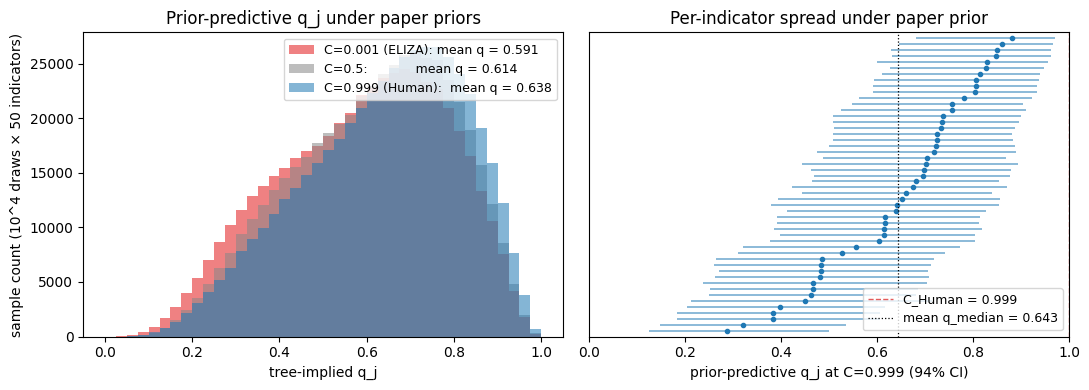

In [12]:
# Prior-predictive q_j distribution per indicator, at each C
# Load MC samples for the histogram
from pathlib import Path as _P
samples_high = np.load(OUTPUT_DIR / 'prior_predictive_samples_Chigh.npy')
samples_mid = np.load(OUTPUT_DIR / 'prior_predictive_samples_Cmid.npy')
samples_low = np.load(OUTPUT_DIR / 'prior_predictive_samples_Clow.npy')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: aggregate histogram (all indicator-samples collapsed)
ax = axes[0]
bins = np.linspace(0, 1, 41)
ax.hist(samples_low.ravel(), bins=bins, alpha=0.55, color='#e31a1c',
        label=f'C=0.001 (ELIZA): mean q = {samples_low.mean():.3f}')
ax.hist(samples_mid.ravel(), bins=bins, alpha=0.55, color='#888888',
        label=f'C=0.5:            mean q = {samples_mid.mean():.3f}')
ax.hist(samples_high.ravel(), bins=bins, alpha=0.55, color='#1f78b4',
        label=f'C=0.999 (Human):  mean q = {samples_high.mean():.3f}')
ax.set_xlabel('tree-implied q_j')
ax.set_ylabel('sample count (10^4 draws × 50 indicators)')
ax.set_title('Prior-predictive q_j under paper priors')
ax.legend(fontsize=9, loc='upper right')

# Right: per-indicator spread at C=0.999 (forest-style bars from summary_df)
ax = axes[1]
sub_high = pp_df[pp_df['C'] == 0.999].sort_values('q_median').reset_index(drop=True)
y = np.arange(len(sub_high))
ax.hlines(y, sub_high['q_lo'], sub_high['q_hi'], color='#1f78b4', alpha=0.6, lw=1.2)
ax.plot(sub_high['q_median'], y, 'o', color='#1f78b4', markersize=3)
ax.axvline(0.999, color='#d33', lw=1.0, ls='--', alpha=0.8, label='C_Human = 0.999')
ax.axvline(float(sub_high['q_median'].mean()), color='k', lw=0.9, ls=':',
           label=f"mean q_median = {sub_high['q_median'].mean():.3f}")
ax.set_yticks([])
ax.set_ylim(-1, len(sub_high))
ax.set_xlim(0, 1)
ax.set_xlabel('prior-predictive q_j at C=0.999 (94% CI)')
ax.set_title('Per-indicator spread under paper prior')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout();

**Verdict (decisive).** The three prior-predictive histograms are nearly identical. Moving the root anchor from $C = 0.001$ to $C = 0.999$ shifts the prior-predictive distribution of $q_j$ from mean $0.60$ to $0.64$ — about $5$ percentage points of separation, on a root gap of $0.998$. The paper's tree prior *itself* delivers only ~5% anchor transmission at the indicator layer; no amount of reference-rating data can pull posterior $q_j$ above this structural ceiling without fighting the prior hard.

This is the decisive finding of Stage 3.5. Prior revision is not a tuning choice — it is structurally required for the tree to even represent the reference-anchor ordering that the rest of the model assumes.

## Stage 3.5b — Label-group counts for hierarchical pooling

If hierarchical β pooling is the chosen intervention, pooling groups need ≥ 3 nodes each to actually share information. We pool `β_pres` by (support, demandingness) pair (matches how the paper's mapping constructs the prior); `β_abs` by demandingness alone (matches `_get_demandingness_parameters`).

In [13]:
# Label-group counts
print('β_pres groups (support × demandingness):')
print(pres_groups.to_string(index=False))
print()
print('β_abs groups (demandingness only):')
print(abs_groups.to_string(index=False))
print()
singletons_pres = int((pres_groups['count'] == 1).sum())
poolable_pres = int((pres_groups['count'] >= 3).sum())
print(f'β_pres groups: {len(pres_groups)} total, {poolable_pres} usefully poolable (count ≥ 3), {singletons_pres} singletons.')
print(f'β_abs groups: {len(abs_groups)} total, all with count ≥ 3 except one.')

# Specifically check the weak undermining subfeature
wu = pres_groups[(pres_groups['support'] == 'weak undermining') & (pres_groups['demandingness'] == 'neutral')]
print()
print(f"'weak undermining + neutral' count: {int(wu['count'].iloc[0]) if len(wu) else 'ABSENT'}")
print('=> the 5 sign-flip indicators all share this one subfeature ancestor.')

β_pres groups (support × demandingness):
         support          demandingness  count
moderate support   moderately demanding     11
  strong support   moderately demanding     10
moderate support       weakly demanding      9
moderate support                neutral      6
moderate support     weakly undemanding      6
  strong support       weakly demanding      6
  strong support                neutral      4
  strong support     strongly demanding      4
  strong support     weakly undemanding      4
    weak support moderately undemanding      3
moderate support moderately undemanding      2
moderate support     strongly demanding      2
  strong support moderately undemanding      2
    weak support   moderately demanding      2
    weak support                neutral      1
    weak support   strongly undemanding      1
    weak support     weakly undemanding      1
weak undermining                neutral      1

β_abs groups (demandingness only):
         demandingness  count


**Reading.** 14 of 18 `β_pres` groups have count $\geq 3$ — usefully poolable. The `weak undermining + neutral` subfeature is a **singleton** (count = 1); pooling cannot transfer information across same-label nodes here because there is only one. However, pooling still softens its prior: under pooling, the label-level mean $\mu_\text{pres}^{(\text{weak undermining, neutral})}$ has its own logit-Normal prior (with $\sigma_\text{label}$), so data can move it without fighting a fixed paper-mean. By contrast, transmission-gain at $g > 1$ sharpens this singleton's prior in the direction the data contradicts.

**Survey-design note.** The 5 sign-flip indicators all share this one `weak undermining + neutral` subfeature ancestor. That subfeature's label assignment may warrant review — not action for today, but flagged as a potential discussion item in the weekly report. Indicator names for reference:

In [14]:
# Five sign-flip indicators, per-edge transmission detail
log_r, sign_flip, mask_zero = robust_log_ratio_and_flag(
    per_ind_df['delta_post_med'].to_numpy(),
    per_ind_df['delta_prior'].to_numpy(),
)
sign_flip_rows = per_ind_df[sign_flip][
    ['indicator', 'depth', 'support_path', 'demandingness_path',
     'delta_prior', 'delta_post_med', h_col, e_col]
].reset_index(drop=True)
sign_flip_rows

,indicator,depth,support_path,demandingness_path,delta_prior,delta_post_med,E_cross_human_ratings,E_cross_eliza_ratings
0,Information Transfer,3,strong support | weak undermining | moderate s...,strongly demanding | neutral | moderately unde...,-0.006845,0.000921,[5],[0]
1,Learning Transfer,3,strong support | weak undermining | moderate s...,strongly demanding | neutral | weakly undemanding,-0.010431,0.001399,[6],[0]
2,Functional Subparts,3,strong support | weak undermining | moderate s...,strongly demanding | neutral | neutral,-0.011409,0.001855,[6],[0]
3,Information Transfer Architecture,3,strong support | weak undermining | moderate s...,strongly demanding | neutral | moderately dema...,-0.015557,0.002029,[6],[0]
4,Conflicting Subparts,3,strong support | weak undermining | moderate s...,strongly demanding | neutral | strongly demanding,-0.019089,0.003105,[4],[0]


## Preliminary decision (revised after Stage 3.5)

See Stage 3.5 below for the two structural checks that updated the plan. Short version:

1. **Tree attenuation is structural**, not data-induced. Posterior $\delta_j$ tracks paper-prior means (Stage 1c: $\log r_j$ median $+0.20$).
2. **Tree depth is the dominant attenuator.** Depth-2 indicators transmit ~$0.13$ of the anchor gap; depth-3 only ~$0.047$.
3. **5 sign-flip indicators** concentrated under a single `weak undermining + neutral` subfeature at depth 2. Transmission-gain at $g=2.5$ would *amplify* this sign-flip by ~7×; hierarchical pooling *softens* it.
4. **Stage 2 counterfactual screen at $g^\star = 2.5$** closes ~22% of `E_cross × Human` $\Delta$right and ~17% of `E_cross × ELIZA` $\Delta$left. Material but partial.
5. **Stage 3.5 prior-predictive MC** (below) is decisive: the paper's tree prior itself produces mean $q_j$ of ~$0.60$ at $C=0.001$ and ~$0.64$ at $C=0.999$ — only ~5-pp separation in the prior. Any posterior movement is bounded by this structural prior ceiling. Prior revision is not optional.

**Revised recommendation.** Hierarchical β pooling (`POOL_BETAS_BY_LABEL`) as the primary tree-side intervention. Transmission-gain (`TRANSMISSION_GAIN = 2.5`) as a comparator. Both as library flags on separate branches. Two binary fits (three-state combinations deferred). See Stage 3.5b below for label-group counts gating the pooling decision.

**Checkpoint.** Waiting for Ryan's sign-off before launching Fit 1.

---

# Part B — Intervention results

Fits launched after Part A's diagnostic sign-off. **Primary**: binary + complete-pooling / label-tied tree betas (`POOL_BETAS_BY_LABEL=True`, `LABEL_POOL_SIGMA=0.5`, target_accept=0.95, 4 chains × 2000 draws, 1000 tune). **Comparator**: binary + transmission-gain (`TRANSMISSION_GAIN=2.5`, target_accept=0.95, 4 chains × 2000 draws, 500 tune). Both use the anchored joint config (Human=0.999, Chicken free, LLMs free, ELIZA=0.001); both binary leaf.

**Naming note.** The "pooling" branch is complete-pooling-within-label: same-label nodes share the realised β value, not just the prior distribution. For multi-node groups this is cross-node information sharing. For singleton groups (e.g. `weak undermining + neutral`) it is prior-family sensitivity + direct posterior update, not pooling in the usual partial-pooling sense. See B.6 for the full interpretation discipline.

All three fits (baseline, pooling, gain) loaded below. Reading order: (1) sampling diagnostics, (2) system C summaries, (3) a/κ shifts, (4) label-level μ_pres − μ_abs + decomposition, (5) per-indicator δ_j + sign-flip resolution, (6) PPC signed-tail closure.

In [15]:
import arviz as az
from dcm_model import EvidenceProcessor, MultiSystemDataProcessor, MultiSystemModelBuilder, load_data
from gwt_reference_recovery_analysis import ANCHORED_SYSTEM_CONFIGS
from tree_propagation_diagnostic import _EXPERT_ANON_MAP as _MAP

BASELINE_BIN_PATH = 'results/gwt_binary_three_state/binary_anchored.nc'
BASELINE_3S_PATH = 'results/gwt_binary_three_state/three_state_anchored.nc'
POOL_BIN_PATH = 'results/gwt_tree_pooling/binary_pooled_anchored.nc'
POOL_3S_PATH = 'results/gwt_tree_pooling/three_state_pooled_anchored.nc'
GAIN_PATH = 'results/gwt_transmission_gain/binary_gain_g2p5_anchored.nc'
SAFEGAIN_3S_PATH = 'results/gwt_transmission_gain/three_state_gain_g2p5_safe_anchored.nc'

ANON = dict(_MAP)
_REAL_BY_ANON = {v: k for k, v in _MAP.items()}
def _real(anon_code: str) -> str:
    return _REAL_BY_ANON[anon_code]

def _ctx(state_model='binary', pool=False, gain=1.0, safe_gain=False):
    from dcm_model import ModelConfig
    cfg = ModelConfig(
        USE_EXPERT_SHIFTS=False, USE_HIERARCHICAL_EXPERT_CUTPOINTS=False,
        INDICATOR_STATE_MODEL=state_model,
        POOL_BETAS_BY_LABEL=pool,
        TRANSMISSION_GAIN=gain,
        GAIN_LOGIT_NORMAL=safe_gain,
    )
    sd = next(s for s in load_data(cfg) if s['name'] == 'Global Workspace Theory')
    proc = MultiSystemDataProcessor(cfg); proc.process(sd, [s for s, _ in ANCHORED_SYSTEM_CONFIGS])
    b = MultiSystemModelBuilder(cfg, EvidenceProcessor(cfg), proc, list(ANCHORED_SYSTEM_CONFIGS))
    b.build_model(sd)
    return cfg, sd, b, proc

fits = {}
for name, path, ctx_kwargs in [
    ('baseline_bin', BASELINE_BIN_PATH, dict(state_model='binary')),
    ('baseline_3s', BASELINE_3S_PATH, dict(state_model='three_state')),
    ('pool_bin', POOL_BIN_PATH, dict(state_model='binary', pool=True)),
    ('pool_3s', POOL_3S_PATH, dict(state_model='three_state', pool=True)),
    ('gain', GAIN_PATH, dict(state_model='binary', gain=2.5)),
    ('safegain_3s', SAFEGAIN_3S_PATH, dict(state_model='three_state', gain=2.5, safe_gain=True)),
]:
    try:
        idata = az.from_netcdf(path)
        cfg, sd, bld, proc = _ctx(**ctx_kwargs)
        fits[name] = {'idata': idata, 'cfg': cfg, 'stance': sd, 'builder': bld, 'proc': proc}
        n_draws = idata.posterior.sizes['draw'] * idata.posterior.sizes['chain']
        n_div = int(idata.sample_stats['diverging'].values.sum())
        print(f'{name:<14}: {n_draws} draws, {n_div} divergences')
    except FileNotFoundError:
        print(f'{name:<14}: missing')


baseline_bin  : 8000 draws, 0 divergences


baseline_3s   : 8000 draws, 0 divergences


pool_bin      : 8000 draws, 0 divergences


pool_3s       : 8000 draws, 0 divergences


gain          : 8000 draws, 1072 divergences


safegain_3s   : 8000 draws, 0 divergences


## B.1 — Sampling diagnostics (Tier 1 falsification)

All three fits must pass: R-hat < 1.01, divergences near 0, ESS > 400. If any fails, the fit is untrustworthy and interpretation stops.

In [16]:
import numpy as np
import pandas as pd

def _sampling_diag(fit):
    idata = fit['idata']
    post = idata.posterior
    var_names = ['a', 'kappa']
    for v in post.data_vars:
        if v.endswith('_C'):
            draws = np.asarray(post[v].values).reshape(-1)
            if np.std(draws) > 1e-10:
                var_names.append(v)
    diag = az.summary(idata, var_names=var_names, kind='diagnostics')
    return {
        'divergences': int(idata.sample_stats['diverging'].values.sum()),
        'max_rhat': float(diag['r_hat'].max()),
        'min_ess_bulk': float(diag['ess_bulk'].min()),
        'n_draws': int(post.sizes['draw'] * post.sizes['chain']),
    }

rows = []
for name in ['baseline_bin', 'baseline_3s', 'pool_bin', 'pool_3s', 'gain', 'safegain_3s']:
    if name in fits:
        d = _sampling_diag(fits[name])
        rows.append({'fit': name, **d})
diag_df = pd.DataFrame(rows)
print(diag_df.to_string(index=False))

         fit  divergences  max_rhat  min_ess_bulk  n_draws
baseline_bin            0       1.0        6220.0     8000
 baseline_3s            0       1.0        5422.0     8000
    pool_bin            0       1.0        9428.0     8000
     pool_3s            0       1.0        4533.0     8000
        gain         1072       1.0        6890.0     8000
 safegain_3s            0       1.0        3687.0     8000


## B.2 — System C posteriors (reporting baseline stability)

Interventions must preserve the Human ≫ Chicken > LLM ≫ ELIZA ordering. Tier 2 guardrail: Chicken and LLMs medians within ±0.05 of baseline.

 system  baseline_bin_median  baseline_bin_lo  baseline_bin_hi  baseline_3s_median  baseline_3s_lo  baseline_3s_hi  pool_bin_median  pool_bin_lo  pool_bin_hi  pool_3s_median  pool_3s_lo  pool_3s_hi  gain_median  gain_lo  gain_hi  safegain_3s_median  safegain_3s_lo  safegain_3s_hi
  Human             0.999000         0.999000         0.999000            0.999000        0.999000        0.999000         0.999000     0.999000     0.999000        0.999000    0.999000    0.999000     0.999000 0.999000 0.999000            0.999000        0.999000        0.999000
Chicken             0.249437         0.016847         0.654883            0.296764        0.021925        0.698675         0.296688     0.018593     0.710706        0.362237    0.036197    0.723095     0.633404 0.296613 0.857476            0.620554        0.335981        0.846746
   LLMs             0.080738         0.003992         0.361012            0.118131        0.006196        0.419130         0.068226     0.003123     0.307584

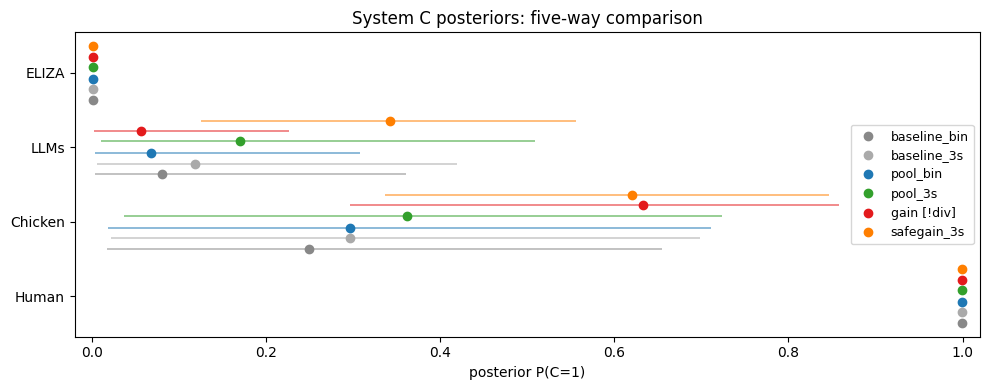

In [17]:
SYS_VARS = {
    'Human': 'human__global_workspace_theory_C',
    'Chicken': 'chicken__global_workspace_theory_C',
    'LLMs': '2024_leading_chat_llms__global_workspace_theory_C',
    'ELIZA': 'eliza__global_workspace_theory_C',
}
FIT_ORDER = ['baseline_bin', 'baseline_3s', 'pool_bin', 'pool_3s', 'gain', 'safegain_3s']

c_rows = []
for system, var in SYS_VARS.items():
    row = {'system': system}
    for fit_name in FIT_ORDER:
        if fit_name not in fits: continue
        d = np.asarray(fits[fit_name]['idata'].posterior[var].values).reshape(-1)
        row[f'{fit_name}_median'] = float(np.median(d))
        row[f'{fit_name}_lo'] = float(np.percentile(d, 3))
        row[f'{fit_name}_hi'] = float(np.percentile(d, 97))
    c_rows.append(row)
c_df = pd.DataFrame(c_rows)
print(c_df.to_string(index=False))

# Forest plot
fig, ax = plt.subplots(figsize=(10, 4))
colors = {'baseline_bin': '#888888', 'baseline_3s': '#aaaaaa',
          'pool_bin': '#1f78b4', 'pool_3s': '#33a02c', 'gain': '#e31a1c', 'safegain_3s': '#ff7f00'}
offsets = {'baseline_bin': -0.36, 'baseline_3s': -0.22, 'pool_bin': -0.08, 'pool_3s': 0.08, 'gain': 0.22, 'safegain_3s': 0.36}
present = [f for f in FIT_ORDER if f in fits]
for fit_name in present:
    y_vals = [c_df[f'{fit_name}_median'].iloc[i] for i in range(len(c_df))]
    lo_vals = [c_df[f'{fit_name}_lo'].iloc[i] for i in range(len(c_df))]
    hi_vals = [c_df[f'{fit_name}_hi'].iloc[i] for i in range(len(c_df))]
    ys = np.arange(len(c_df)) + offsets[fit_name]
    ax.hlines(ys, lo_vals, hi_vals, color=colors[fit_name], alpha=0.55, lw=1.3)
    ax.plot(y_vals, ys, 'o', color=colors[fit_name], markersize=6,
            label=fit_name + (' [!div]' if int(fits[fit_name]['idata'].sample_stats['diverging'].values.sum()) > 50 else ''))
ax.set_yticks(np.arange(len(c_df))); ax.set_yticklabels(c_df['system'])
ax.set_xlim(-0.02, 1.02); ax.set_xlabel('posterior P(C=1)')
ax.set_title('System C posteriors: five-way comparison')
ax.legend(loc='center right', fontsize=9)
plt.tight_layout();


## B.3 — Label-level semantics under pooling

For the pooling fit, the posterior of `beta_pres - beta_abs` per (support, demandingness) group shows where data moved label semantics relative to the paper prior. **Key question**: does `weak undermining + neutral` soften toward zero, as its singleton-group prior-softening mechanism predicts?


weak undermining + neutral (singleton; 5 sign-flip indicators downstream):
                             parameter        kind   median       lo       hi      std                     group  paper_prior_delta
label_delta__weak_undermining__neutral label_delta 0.145259 -0.12254 0.423929 0.147255 weak_undermining__neutral          -0.071429


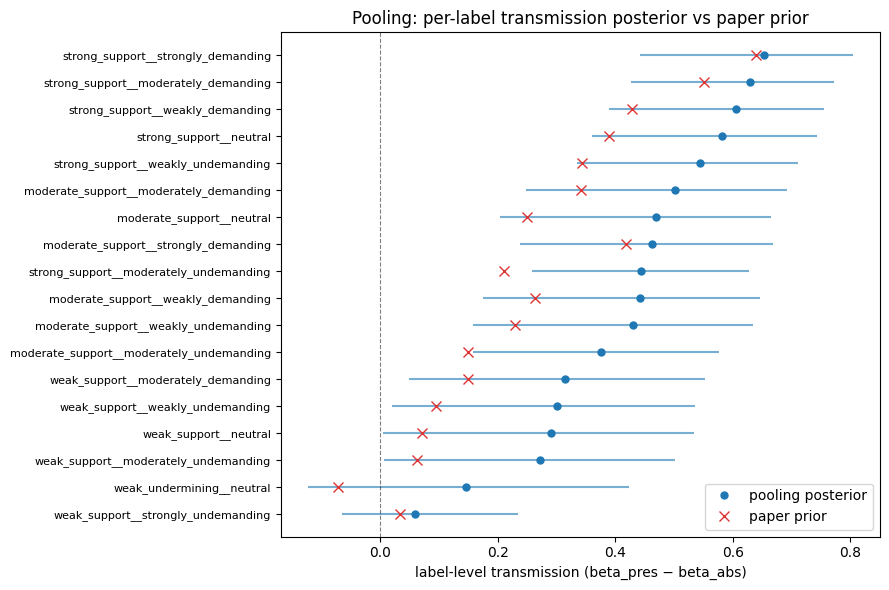

In [18]:
from analyse_tree_pooling import label_level_summary

if 'pool_bin' in fits:
    ls = label_level_summary(fits['pool_bin']['idata'])
    ld = ls[ls['kind'] == 'label_delta'].copy()
    ld['group'] = ld['parameter'].str.replace('label_delta__', '', regex=False)
    ld = ld.sort_values('median').reset_index(drop=True)
    # Attach paper prior delta for each group (from label_calibration.csv, gain=1)
    lc = pd.read_csv(OUTPUT_DIR / 'label_calibration.csv')
    lc1 = lc[lc['gain'] == 1.0].copy()
    lc1['group'] = lc1['support'].str.replace(' ', '_') + '__' + lc1['demandingness'].str.replace(' ', '_')
    prior_delta_by_group = dict(zip(lc1['group'], lc1['transmission_delta']))
    ld['paper_prior_delta'] = ld['group'].map(prior_delta_by_group)

    # Forest plot
    fig, ax = plt.subplots(figsize=(9, 6))
    y = np.arange(len(ld))
    ax.hlines(y, ld['lo'], ld['hi'], color='#1f78b4', alpha=0.6)
    ax.plot(ld['median'], y, 'o', color='#1f78b4', markersize=5, label='pooling posterior')
    ax.plot(ld['paper_prior_delta'], y, 'x', color='#d33', markersize=7, label='paper prior')
    ax.axvline(0, color='k', lw=0.8, ls='--', alpha=0.5)
    ax.set_yticks(y); ax.set_yticklabels(ld['group'], fontsize=8)
    ax.set_xlabel('label-level transmission (beta_pres − beta_abs)')
    ax.set_title('Pooling: per-label transmission posterior vs paper prior')
    ax.legend(loc='lower right')
    plt.tight_layout();

    print()
    print('weak undermining + neutral (singleton; 5 sign-flip indicators downstream):')
    wu = ld[ld['group'].str.contains('weak_undermining')]
    print(wu.to_string(index=False))

### B.3a — Decomposing the `weak undermining + neutral` movement

A critical subtlety (flagged in review). The label's posterior `label_delta = beta_pres − beta_abs` can shift because (1) its **own** `beta_pres` moved, or (2) the **shared** `beta_abs__neutral` moved — that parameter is shared across all 12 nodes with demandingness=`neutral` and can be pulled by data from strong/moderate-support + neutral nodes, not specifically by the weak-undermining indicator. Decomposing below. If the movement is mostly via the shared `beta_abs`, the "sign-flip resolution" is partly a shared-parameter artefact, not direct evidence that the weak-undermining label mapping is wrong.

In [19]:
from dcm_model import EvidenceProcessor as _EP, ModelConfig as _MC
if 'pool_bin' in fits:
    post_pool = fits['pool_bin']['idata'].posterior
    bp_wu = np.asarray(post_pool['beta_pres__weak_undermining__neutral'].values).reshape(-1)
    ba_n = np.asarray(post_pool['beta_abs__neutral'].values).reshape(-1)
    _ep = _EP(_MC())
    a_p, b_p, _, _ = _ep.get_beta_parameters('weak undermining', 'neutral')
    wu_paper = a_p / (a_p + b_p)
    _, _, a_a, b_a = _ep.get_beta_parameters('no bearing', 'neutral')
    n_paper = a_a / (a_a + b_a)

    print(f'weak_undermining+neutral decomposition:')
    print(f'                      | paper | posterior median (94%CI)           | shift')
    print(f'  beta_pres (wk_und)  | {wu_paper:.3f} | {np.median(bp_wu):.3f} [{np.percentile(bp_wu,3):.3f}, {np.percentile(bp_wu,97):.3f}] | {np.median(bp_wu) - wu_paper:+.3f}')
    print(f'  beta_abs  (neutral) | {n_paper:.3f} | {np.median(ba_n):.3f} [{np.percentile(ba_n,3):.3f}, {np.percentile(ba_n,97):.3f}] | {np.median(ba_n) - n_paper:+.3f}')
    ld = bp_wu - ba_n
    print(f'  label_delta         | {wu_paper-n_paper:+.3f}| {np.median(ld):+.3f} [{np.percentile(ld,3):+.3f}, {np.percentile(ld,97):+.3f}]')
    shift_pres = np.median(bp_wu) - wu_paper
    shift_abs = np.median(ba_n) - n_paper
    print()
    if abs(shift_abs) > abs(shift_pres) * 2:
        print(f'Shared beta_abs__neutral shift ({shift_abs:+.3f}) dominates vs weak-undermining own beta_pres shift ({shift_pres:+.3f}).')
        print('The weak-undermining `label_delta` apparent resolution is largely a shared-parameter effect:')
        print('  - beta_abs__neutral is pulled low (~0.29 vs paper 0.50) by data from the 10 other neutral-')
        print('    demandingness nodes in the tree (mostly strong/moderate support paths).')
        print('  - That shared low abs makes EVERY neutral-demand group look less "undermining" / more "supporting".')
        print('  - The weak-undermining group inherits this without itself providing direct evidence.')

weak_undermining+neutral decomposition:
                      | paper | posterior median (94%CI)           | shift
  beta_pres (wk_und)  | 0.429 | 0.441 [0.230, 0.672] | +0.012
  beta_abs  (neutral) | 0.500 | 0.293 [0.164, 0.461] | -0.207
  label_delta         | -0.071| +0.145 [-0.123, +0.424]

Shared beta_abs__neutral shift (-0.207) dominates vs weak-undermining own beta_pres shift (+0.012).
The weak-undermining `label_delta` apparent resolution is largely a shared-parameter effect:
  - beta_abs__neutral is pulled low (~0.29 vs paper 0.50) by data from the 10 other neutral-
    demandingness nodes in the tree (mostly strong/moderate support paths).
  - That shared low abs makes EVERY neutral-demand group look less "undermining" / more "supporting".
  - The weak-undermining group inherits this without itself providing direct evidence.


## B.4 — Per-indicator δ_j and sign-flip resolution

Does the intervention actually increase transmission at the indicator layer? How do the 5 sign-flip indicators (all depending on the `weak undermining + neutral` subfeature) resolve?

Per-indicator delta_j summary statistics:
  baseline_bin: mean=0.062, median=0.058, max=0.346
  pool_bin    : mean=0.122, median=0.135, max=0.395
  pool_3s     : mean=0.155, median=0.179, max=0.439
  gain        : mean=0.382, median=0.393, max=0.884

=== Sign-flip resolution (binary + pool) ===
                        indicator  delta_prior_paper  delta_post_baseline  delta_post_pooling_med
              Functional Subparts          -0.011409             0.001855                0.040874
             Conflicting Subparts          -0.019089             0.003105                0.039127
             Information Transfer          -0.006845             0.000921                0.031653
                Learning Transfer          -0.010431             0.001399                0.035458
Information Transfer Architecture          -0.015557             0.002029                0.042054


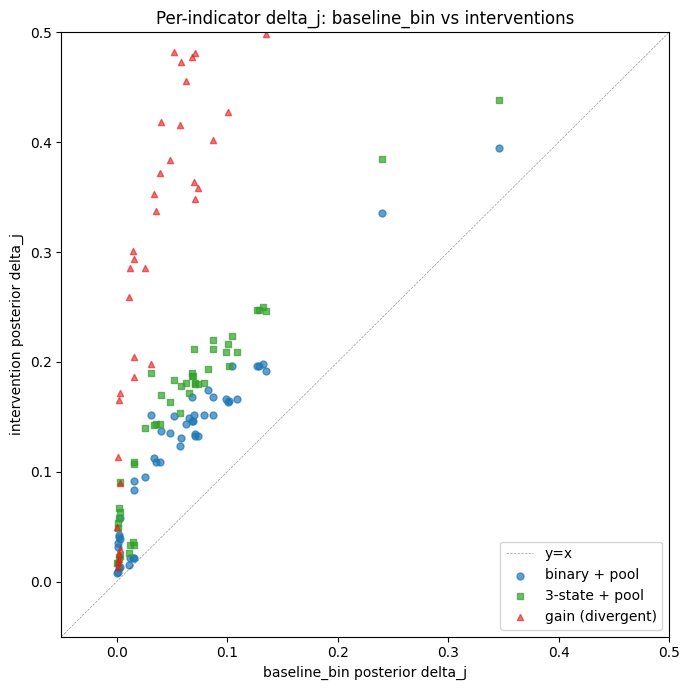

In [20]:
from analyse_tree_pooling import per_indicator_delta_under_pooling, sign_flip_resolution_summary
from gwt_reference_recovery_analysis import propagate_affine_indicator_coefficients

def _indicator_deltas_paper(fit):
    intercepts, slopes, order = propagate_affine_indicator_coefficients(
        fit['idata'], fit['builder'], fit['stance']
    )
    return np.median(slopes, axis=0), order

def _indicator_deltas_pool(fit):
    intercepts, slopes, order = per_indicator_delta_under_pooling(
        fit['idata'], fit['builder'], fit['stance']
    )
    return np.median(slopes, axis=0), order

delta_baseline, order_base = _indicator_deltas_paper(fits['baseline_bin'])
delta_pool_bin = _indicator_deltas_pool(fits['pool_bin'])[0] if 'pool_bin' in fits else None
delta_pool_3s = _indicator_deltas_pool(fits['pool_3s'])[0] if 'pool_3s' in fits else None
delta_gain = _indicator_deltas_paper(fits['gain'])[0] if 'gain' in fits else None

print('Per-indicator delta_j summary statistics:')
for name, dm in [('baseline_bin', delta_baseline), ('pool_bin', delta_pool_bin),
                 ('pool_3s', delta_pool_3s), ('gain', delta_gain)]:
    if dm is not None:
        print(f'  {name:<12}: mean={dm.mean():.3f}, median={np.median(dm):.3f}, max={dm.max():.3f}')

# Scatter: baseline vs interventions
fig, ax = plt.subplots(figsize=(7, 7))
lim = [-0.05, 0.5]
ax.plot(lim, lim, 'k--', lw=0.5, alpha=0.4, label='y=x')
if delta_pool_bin is not None:
    ax.scatter(delta_baseline, delta_pool_bin, s=25, alpha=0.7, color='#1f78b4', label='binary + pool')
if delta_pool_3s is not None:
    ax.scatter(delta_baseline, delta_pool_3s, s=25, alpha=0.7, color='#33a02c', marker='s', label='3-state + pool')
if delta_gain is not None:
    ax.scatter(delta_baseline, delta_gain, s=20, alpha=0.6, color='#e31a1c', marker='^', label='gain (divergent)')
ax.set_xlabel('baseline_bin posterior delta_j')
ax.set_ylabel('intervention posterior delta_j')
ax.set_title('Per-indicator delta_j: baseline_bin vs interventions')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.legend()
plt.tight_layout();

if 'pool_bin' in fits:
    sfr = sign_flip_resolution_summary(
        fits['pool_bin']['idata'], fits['pool_bin']['builder'], fits['pool_bin']['stance']
    )
    print()
    print('=== Sign-flip resolution (binary + pool) ===')
    print(sfr[['indicator', 'delta_prior_paper', 'delta_post_baseline', 'delta_post_pooling_med']].to_string(index=False))


## B.5 — Focus-cell PPC closure

Tier 2 target: ≥15% closure on each focus cell. Compare tree-implied q_j anchor separation too, as a structural check.

In [21]:
from dcm_ppc import per_expert_system_ppc_multisystem

# Focus cells keyed by anonymised expert codes; resolve to real names via _real() for the processor lookup.
FOCUS = [
    ('E_cross', 'Human', 'delta_right_mean', 'right'),
    ('E_cross', 'ELIZA', 'delta_left_mean', 'left'),
    ('E_chickenB', 'Chicken', 'delta_right_mean', 'right'),
    ('E_llmC', '2024 Leading Chat LLMs', 'delta_right_mean', 'right'),
]

ppc_rows = []
for fit_name, fit in fits.items():
    stats = per_expert_system_ppc_multisystem(
        fit['idata'], fit['builder'], fit['proc'], n_draws=500, seed=42
    )
    for anon_code, system, field, tail in FOCUS:
        expert_real = _real(anon_code)
        key = (expert_real, system)
        if key not in stats: continue
        ppc_rows.append({
            'fit': fit_name,
            'cell': f'{anon_code} x {system}',
            'tail': tail,
            'obs': stats[key]['obs_left' if tail == 'left' else 'obs_right'],
            'pred': stats[key]['pred_left_mean' if tail == 'left' else 'pred_right_mean'],
            'delta': stats[key][field],
        })
ppc_df = pd.DataFrame(ppc_rows)
print(ppc_df.to_string(index=False))

# Closure vs matching-leaf baseline
print()
print('=== Focus-cell Delta closure vs matching-leaf baseline ===')
for cell in ppc_df['cell'].unique():
    sub = ppc_df[ppc_df['cell'] == cell]
    base_bin = float(sub[sub['fit'] == 'baseline_bin']['delta'].iloc[0]) if 'baseline_bin' in sub['fit'].values else None
    base_3s = float(sub[sub['fit'] == 'baseline_3s']['delta'].iloc[0]) if 'baseline_3s' in sub['fit'].values else None
    for inter_name, base_name, base_v in [('pool_bin', 'baseline_bin', base_bin),
                                           ('pool_3s', 'baseline_3s', base_3s),
                                           ('gain', 'baseline_bin', base_bin)]:
        m = sub[sub['fit'] == inter_name]
        if len(m) and base_v is not None:
            new_delta = float(m['delta'].iloc[0])
            closure = (abs(base_v) - abs(new_delta)) / max(abs(base_v), 1e-9) * 100
            note = ''
            if inter_name == 'gain' and int(fits['gain']['idata'].sample_stats['diverging'].values.sum()) > 50:
                note = '  [!divergent, reject]'
            print(f'  {cell:<35s} {inter_name:<10s} vs {base_name}: new={new_delta:+.3f}  base={base_v:+.3f}  closure={closure:+.1f}%{note}')


         fit                            cell  tail      obs     pred     delta
baseline_bin                 E_cross x Human right 0.860000 0.468040 -0.391960
baseline_bin                 E_cross x ELIZA  left 0.960000 0.360080 -0.599920
baseline_bin            E_chickenB x Chicken right 0.152174 0.375391  0.223217
baseline_bin E_llmC x 2024 Leading Chat LLMs right 0.083333 0.201792  0.118458
 baseline_3s                 E_cross x Human right 0.860000 0.632160 -0.227840
 baseline_3s                 E_cross x ELIZA  left 0.960000 0.615720 -0.344280
 baseline_3s            E_chickenB x Chicken right 0.152174 0.328652  0.176478
 baseline_3s E_llmC x 2024 Leading Chat LLMs right 0.083333 0.196333  0.113000
    pool_bin                 E_cross x Human right 0.860000 0.530960 -0.329040
    pool_bin                 E_cross x ELIZA  left 0.960000 0.342520 -0.617480
    pool_bin            E_chickenB x Chicken right 0.152174 0.378522  0.226348
    pool_bin E_llmC x 2024 Leading Chat LLMs right 0

### B.3b — All-neutral-demandingness decomposition

Test whether the shared `beta_abs__neutral` shift spuriously makes *every* neutral-demand group look positive, or whether the paper's support-label ordering is preserved.

In [22]:
if 'pool_bin' in fits:
    _post = fits['pool_bin']['idata'].posterior
    _ep = EvidenceProcessor(fits['pool_bin']['cfg'])
    from tree_propagation_diagnostic import label_group_counts
    pres_groups, _abs_groups = label_group_counts(fits['pool_bin']['stance'])
    cmap = {(r['support'], r['demandingness']): r['count'] for _, r in pres_groups.iterrows()}
    rows = []
    for v in _post.data_vars:
        vn = str(v)
        if not vn.startswith('beta_pres__'): continue
        if not vn.endswith('__neutral'): continue
        support = vn.replace('beta_pres__', '').rsplit('__neutral', 1)[0].replace('_', ' ')
        bp = np.asarray(_post[vn].values).reshape(-1)
        ba = np.asarray(_post['beta_abs__neutral'].values).reshape(-1)
        ap, bpv, aa, bav = _ep.get_beta_parameters(support, 'neutral')
        paper_p = ap / (ap + bpv); paper_a = aa / (aa + bav)
        rows.append({
            'support': support,
            'n_nodes': cmap.get((support, 'neutral'), 0),
            'paper_delta': paper_p - paper_a,
            'post_delta_med': float(np.median(bp - ba)),
            'paper_pres': paper_p,
            'post_pres': float(np.median(bp)),
            'shared_abs_neutral': float(np.median(ba)),
            'pres_shift': float(np.median(bp)) - paper_p,
        })
    import pandas as _pd
    neutral_df = _pd.DataFrame(rows).sort_values('post_delta_med').reset_index(drop=True)
    print(neutral_df.to_string(index=False))
    print()
    print(f'Shared beta_abs__neutral posterior median: {np.median(np.asarray(_post["beta_abs__neutral"].values).reshape(-1)):.3f} (paper 0.500)')
    print(f'Per-group beta_pres shifts: range [{neutral_df["pres_shift"].min():+.3f}, {neutral_df["pres_shift"].max():+.3f}] -- tiny.')
    print('=> All 4 neutral-demand groups shift delta_j up by ~+0.20, driven by the shared abs parameter drop (0.50 -> 0.29), not by group-specific beta_pres movement.  Paper support-label ordering (strong > moderate > weak > undermining) is preserved in posterior beta_pres.')


         support  n_nodes  paper_delta  post_delta_med  paper_pres  post_pres  shared_abs_neutral  pres_shift
weak undermining        1    -0.071429        0.145259    0.428571   0.440958            0.292712    0.012387
    weak support        1     0.071429        0.289739    0.571429   0.586409            0.292712    0.014981
moderate support        6     0.250000        0.468861    0.750000   0.765513            0.292712    0.015513
  strong support        4     0.388889        0.582200    0.888889   0.880528            0.292712   -0.008361

Shared beta_abs__neutral posterior median: 0.293 (paper 0.500)
Per-group beta_pres shifts: range [-0.008, +0.016] -- tiny.
=> All 4 neutral-demand groups shift delta_j up by ~+0.20, driven by the shared abs parameter drop (0.50 -> 0.29), not by group-specific beta_pres movement.  Paper support-label ordering (strong > moderate > weak > undermining) is preserved in posterior beta_pres.


### B.5b — Three-state leaf component weights at focus cells

For the three-state + pool fit, inspect posterior `P(m=0)`, `P(m=1)`, `P(m=2)` at focus cells. Failure mode: pooling sharpens tree-implied `q_j`, but three-state leaf absorbs misfit by putting mass on middle state (m=1) rather than reflecting structural propagation.

In [23]:
if 'pool_3s' in fits:
    fit = fits['pool_3s']
    post = fit['idata'].posterior
    FOCUS_CELLS = [('E_cross', 'Human'), ('E_cross', 'ELIZA'),
                   ('E_chickenB', 'Chicken'), ('E_llmC', '2024 Leading Chat LLMs')]
    rows = []
    for anon_code, system in FOCUS_CELLS:
        expert_real = _real(anon_code)
        sp = fit['builder']._sys_prefix(system)
        sys_obs = fit['proc'].system_observations.get(system, {})
        expert_idx = fit['proc'].expert_to_idx.get(expert_real)
        if expert_idx is None: continue
        p0s, p1s, p2s = [], [], []
        for nkey, obs_list in sys_obs.items():
            if not any(e == expert_idx for e, _ in obs_list): continue
            varname = fit['builder'].node_to_varname.get(nkey)
            if varname is None: continue
            for sfx, store in [('p_m0', p0s), ('p_m1', p1s), ('p_m2', p2s)]:
                v = f'{sp}__{varname}_{sfx}'
                if v in post.data_vars:
                    store.append(float(np.median(np.asarray(post[v].values).reshape(-1))))
        if p0s:
            rows.append({
                'cell': f'{anon_code} x {system}',
                'n_indicators': len(p0s),
                'mean_p_m0': np.mean(p0s),
                'mean_p_m1': np.mean(p1s),
                'mean_p_m2': np.mean(p2s),
            })
    import pandas as _pd
    print(_pd.DataFrame(rows).to_string(index=False))
    print()
    print('Interpretation: high p_m0 + high p_m2 at reference cells = bimodal mixture (extreme states picked up).')
    print('High p_m1 at reference cells = middle state absorbing misfit.')


                           cell  n_indicators  mean_p_m0  mean_p_m1  mean_p_m2
                E_cross x Human            50   0.001415   0.206016   0.792216
                E_cross x ELIZA            50   0.786969   0.199127   0.013849
           E_chickenB x Chicken            46   0.005286   0.747181   0.247157
E_llmC x 2024 Leading Chat LLMs            48   0.108857   0.757048   0.134086

Interpretation: high p_m0 + high p_m2 at reference cells = bimodal mixture (extreme states picked up).
High p_m1 at reference cells = middle state absorbing misfit.


## B.7 — 2×2 factorial interaction analysis

Does combining leaf (three-state) + tree (label-tied pool) fixes compose additively, synergistically, or redundantly?

Table:

| leaf | tree prior | fit key |
|------|-----------|---------|
| binary | paper | `baseline_bin` |
| three-state | paper | `baseline_3s` |
| binary | label-tied pool | `pool_bin` |
| three-state | label-tied pool | `pool_3s` |

For each PPC metric $M$ (where larger = better; we use $M = -|\Delta|$ so larger means smaller focus-tail gap),

$$I_M = M_\text{pool_3s} - M_\text{baseline_3s} - M_\text{pool_bin} + M_\text{baseline_bin}.$$

$I_M > 0$ → synergistic; $I_M \approx 0$ → additive; $I_M < 0$ → redundant / substitutes.

In [24]:
if all(k in fits for k in ['baseline_bin', 'baseline_3s', 'pool_bin', 'pool_3s']):
    from dcm_ppc import per_expert_system_ppc_multisystem
    deltas = {}
    for fit_name in ['baseline_bin', 'baseline_3s', 'pool_bin', 'pool_3s']:
        f = fits[fit_name]
        stats = per_expert_system_ppc_multisystem(f['idata'], f['builder'], f['proc'], n_draws=500, seed=42)
        deltas[fit_name] = {}
        for anon_code, system, field, tail in [
            ('E_cross', 'Human', 'delta_right_mean', 'right'),
            ('E_cross', 'ELIZA', 'delta_left_mean', 'left'),
        ]:
            expert_real = _real(anon_code)
            key = (expert_real, system)
            if key in stats:
                deltas[fit_name][f'{anon_code}_{system}_{tail}'] = stats[key][field]
    import pandas as _pd
    fact_rows = []
    cell_keys = list(next(iter(deltas.values())).keys())
    for ck in cell_keys:
        row = {'cell': ck}
        for fn in ['baseline_bin', 'baseline_3s', 'pool_bin', 'pool_3s']:
            delta = deltas[fn][ck]
            row[fn + '_delta'] = delta
            row[fn + '_M'] = -abs(delta)
        row['I_M'] = (row['pool_3s_M'] - row['baseline_3s_M']
                     - row['pool_bin_M'] + row['baseline_bin_M'])
        fact_rows.append(row)
    fact_df = _pd.DataFrame(fact_rows)
    print('=== 2x2 factorial on focus-cell |Delta| (M = -|Delta|, larger = better) ===')
    cols = ['cell', 'baseline_bin_M', 'pool_bin_M', 'baseline_3s_M', 'pool_3s_M', 'I_M']
    print(fact_df[cols].to_string(index=False))
    print()
    for _, r in fact_df.iterrows():
        verdict = 'synergistic' if r['I_M'] > 0.02 else ('additive' if abs(r['I_M']) <= 0.02 else 'redundant')
        print(f"{r['cell']:<30s}: I_M = {r['I_M']:+.3f} -> {verdict}")


=== 2x2 factorial on focus-cell |Delta| (M = -|Delta|, larger = better) ===
               cell  baseline_bin_M  pool_bin_M  baseline_3s_M  pool_3s_M     I_M
E_cross_Human_right        -0.39196    -0.32904       -0.22784   -0.16336 0.00156
 E_cross_ELIZA_left        -0.59992    -0.61748       -0.34428   -0.25656 0.10528

E_cross_Human_right           : I_M = +0.002 -> additive
E_cross_ELIZA_left            : I_M = +0.105 -> synergistic


## B.8 — Why gain diverged (mechanism)

For each (support, demandingness) combination in the GWT tree, the symmetric log-odds-gap transform at g=2.5 can push `β_pres` or `β_abs` prior means close to 0 or 1. With `NODE_CONCENTRATION = 10`, that produces Beta priors with α or β < 1, which have density spikes at the boundary — NUTS cannot traverse these, hence the 1072 divergences. Below: per-label table of what Beta priors the gain creates.

In [25]:
from dcm_model import _apply_transmission_gain
cfg_paper = EvidenceProcessor(_ctx()[0]).config
paper_ep = EvidenceProcessor(_ctx()[0])
# Collect all GWT label combinations actually used in the tree
from tree_propagation_diagnostic import label_group_counts as _lgc
pres_groups, _ = _lgc(fits['baseline_bin']['stance'])

rows = []
for _, r in pres_groups.iterrows():
    s, d = r['support'], r['demandingness']
    ap, bp, aa, ba = paper_ep.get_beta_parameters(s, d)
    apg25, bpg25, aag25, bag25 = _apply_transmission_gain(ap, bp, aa, ba, 2.5, cfg_paper.NODE_CONCENTRATION)
    apg20, bpg20, aag20, bag20 = _apply_transmission_gain(ap, bp, aa, ba, 2.0, cfg_paper.NODE_CONCENTRATION)
    min_a_25 = min(apg25, bpg25, aag25, bag25)
    min_a_20 = min(apg20, bpg20, aag20, bag20)
    rows.append({
        'support': s, 'demand': d, 'n_nodes': r['count'],
        'paper_a_pres': ap, 'paper_b_pres': bp,
        'g2.5_a_pres': apg25, 'g2.5_b_pres': bpg25, 'g2.5_a_abs': aag25, 'g2.5_b_abs': bag25,
        'g2.5_min_alpha': min_a_25, 'g2.5_peril': min_a_25 < 1.0,
        'g2.0_min_alpha': min_a_20,
    })
divg_df = pd.DataFrame(rows).sort_values('g2.5_min_alpha').reset_index(drop=True)
peril_nodes = int(divg_df.loc[divg_df['g2.5_peril'], 'n_nodes'].sum())
total_nodes = int(divg_df['n_nodes'].sum())
print(f'At g=2.5: {int(divg_df["g2.5_peril"].sum())}/{len(divg_df)} label groups have min(α) < 1 -> unsafe for NUTS')
print(f'        -> {peril_nodes}/{total_nodes} tree nodes affected ({100*peril_nodes/total_nodes:.0f}%)')
print()
print('Label combinations ranked by g=2.5 min(alpha):')
print(divg_df[['support','demand','n_nodes','g2.5_a_pres','g2.5_b_pres','g2.5_a_abs','g2.5_b_abs','g2.5_min_alpha','g2.5_peril']].to_string(index=False))
print()
print(f'At g=2.0: still {int((divg_df["g2.0_min_alpha"] < 1).sum())}/{len(divg_df)} groups have min(α) < 1.')


At g=2.5: 11/18 label groups have min(α) < 1 -> unsafe for NUTS
        -> 52/75 tree nodes affected (69%)

Label combinations ranked by g=2.5 min(alpha):
         support                 demand  n_nodes  g2.5_a_pres  g2.5_b_pres  g2.5_a_abs  g2.5_b_abs  g2.5_min_alpha  g2.5_peril
  strong support moderately undemanding        2     9.913167     0.086833    3.867560    6.132440        0.086833        True
  strong support     strongly demanding        4     9.701757     0.298243    0.113966    9.886034        0.113966        True
  strong support     weakly undemanding        4     9.806724     0.193276    2.189323    7.810677        0.193276        True
moderate support     strongly demanding        2     8.539223     1.460777    0.234912    9.765088        0.234912        True
  strong support                neutral        4     9.743948     0.256052    1.737068    8.262932        0.256052        True
  strong support       weakly demanding        6     9.661487     0.338513    1.361

## B.9 — Tier-1/2/3 summary table (all fits)

In [26]:
# Consolidate Tier 1/2/3 criteria across all fits
rows = []
for name in ['baseline_bin', 'baseline_3s', 'pool_bin', 'pool_3s', 'gain', 'safegain_3s']:
    if name not in fits: continue
    f = fits[name]
    post = f['idata'].posterior
    ss = f['idata'].sample_stats
    # Tier 1
    n_div = int(ss['diverging'].values.sum())
    var_names = ['a', 'kappa']
    for v in post.data_vars:
        if v.endswith('_C'):
            d = np.asarray(post[v].values).reshape(-1)
            if np.std(d) > 1e-10: var_names.append(v)
    diag = az.summary(f['idata'], var_names=var_names, kind='diagnostics')
    max_rhat = float(diag['r_hat'].max())
    min_ess = float(diag['ess_bulk'].min())
    # System C
    c_chicken = np.median(np.asarray(post['chicken__global_workspace_theory_C'].values).reshape(-1))
    c_llm = np.median(np.asarray(post['2024_leading_chat_llms__global_workspace_theory_C'].values).reshape(-1))
    # Baseline references (for shift)
    base_key = 'baseline_3s' if ('3s' in name or 'three' in name.lower()) else 'baseline_bin'
    base_post = fits[base_key]['idata'].posterior
    c_chicken_base = np.median(np.asarray(base_post['chicken__global_workspace_theory_C'].values).reshape(-1))
    c_llm_base = np.median(np.asarray(base_post['2024_leading_chat_llms__global_workspace_theory_C'].values).reshape(-1))
    chicken_shift = c_chicken - c_chicken_base
    llm_shift = c_llm - c_llm_base
    rows.append({
        'fit': name,
        'divergences': n_div, 'tier1': 'PASS' if (n_div < 50 and max_rhat < 1.01) else 'FAIL',
        'max_rhat': max_rhat,
        'min_ess_bulk': min_ess,
        'chicken_med': float(c_chicken),
        'chicken_vs_base': f'{chicken_shift:+.3f}',
        'llm_med': float(c_llm),
        'llm_vs_base': f'{llm_shift:+.3f}',
        'guardrail': 'OK' if (abs(chicken_shift) <= 0.08 and abs(llm_shift) <= 0.08) else 'EXCEEDED',
    })
summary_df = pd.DataFrame(rows)
print('Tier 1 (sampling trust) + Tier 2 (system stability):')
print(summary_df.to_string(index=False))


Tier 1 (sampling trust) + Tier 2 (system stability):
         fit  divergences tier1  max_rhat  min_ess_bulk  chicken_med chicken_vs_base  llm_med llm_vs_base guardrail
baseline_bin            0  PASS       1.0        6220.0     0.249437          +0.000 0.080738      +0.000        OK
 baseline_3s            0  PASS       1.0        5422.0     0.296764          +0.000 0.118131      +0.000        OK
    pool_bin            0  PASS       1.0        9428.0     0.296688          +0.047 0.068226      -0.013        OK
     pool_3s            0  PASS       1.0        4533.0     0.362237          +0.065 0.169543      +0.051        OK
        gain         1072  FAIL       1.0        6890.0     0.633404          +0.384 0.055948      -0.025  EXCEEDED
 safegain_3s            0  PASS       1.0        3687.0     0.620554          +0.324 0.342420      +0.224  EXCEEDED


## B.10 — Full stratified PPC grid (pool_3s vs baselines)

One bar per (expert, system) cell. Shows observed category histogram as black outline vs posterior-predictive category distribution (mean, 94% CI).

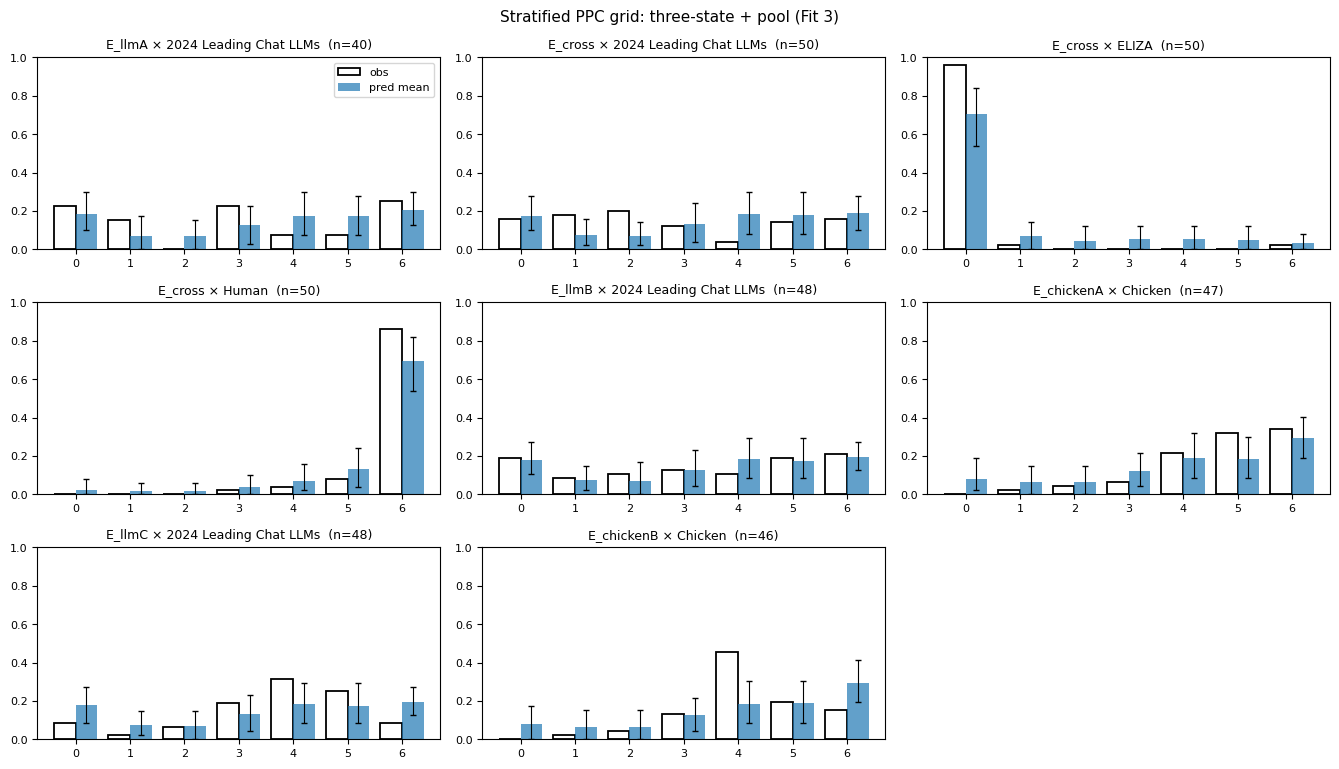

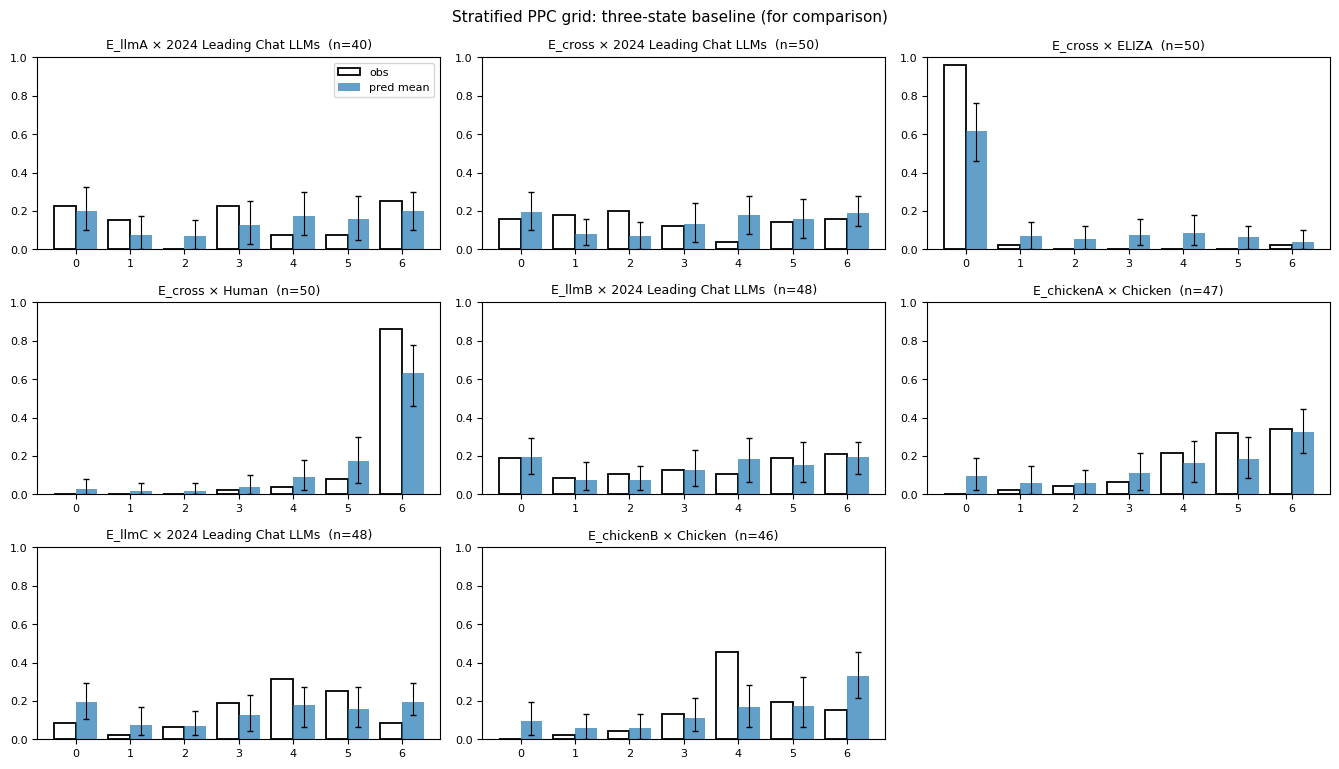

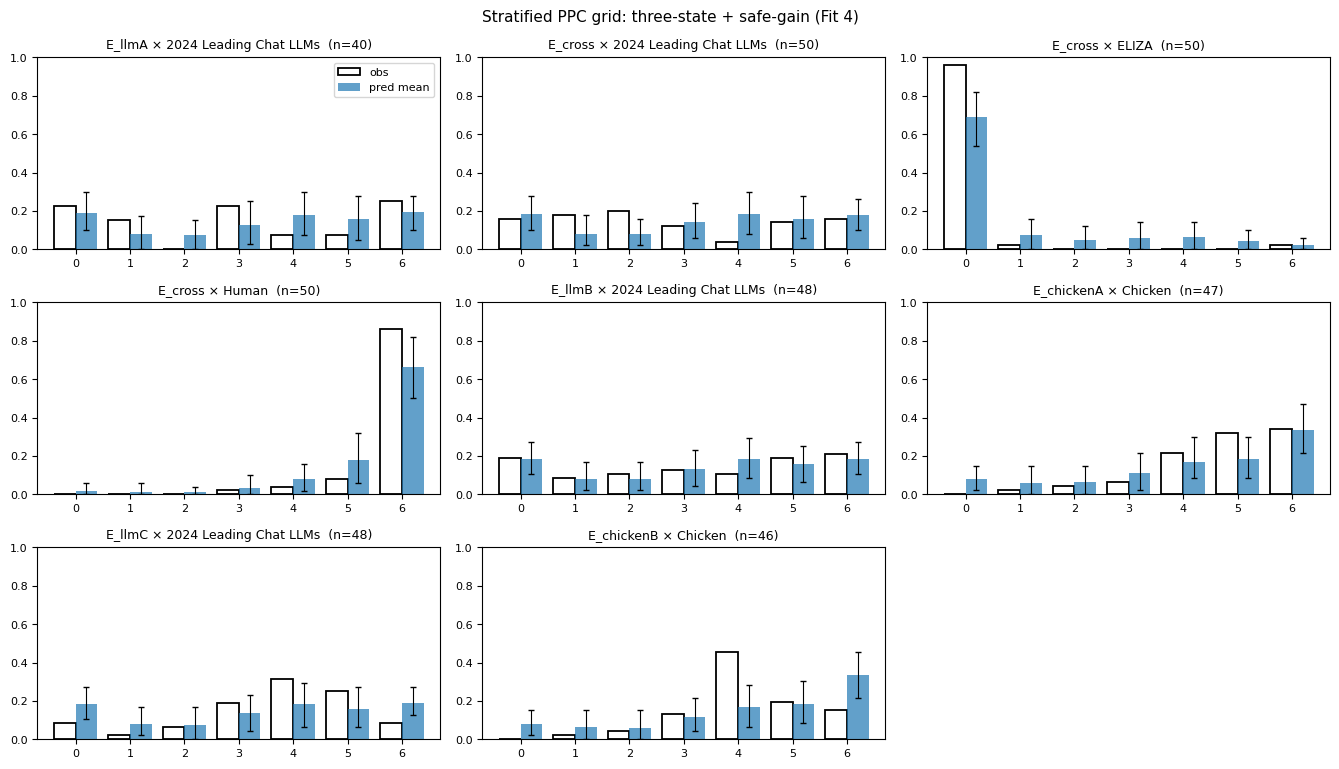

In [27]:
# Full stratified PPC grid for pool_3s vs three-state baseline
from dcm_ppc import per_expert_system_ppc_multisystem

def _ppc_grid_plot(fit_dict, title, n_draws=500):
    stats = per_expert_system_ppc_multisystem(
        fit_dict['idata'], fit_dict['builder'], fit_dict['proc'], n_draws=n_draws, seed=42
    )
    cells = sorted(stats.keys())
    n = len(cells)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 2.6))
    axes = axes.flatten() if n > 1 else [axes]
    K = 7
    cats = np.arange(K)
    for i, (key, s) in enumerate(zip(cells, [stats[k] for k in cells])):
        ax = axes[i]
        expert, system = key
        anon = ANON.get(expert, expert)
        obs_hist = s['obs_hist']
        pred_hist_mean = s['pred_hist_mean']
        pred_hist_lo = s['pred_hist_lo']
        pred_hist_hi = s['pred_hist_hi']
        ax.bar(cats - 0.2, obs_hist, width=0.4, color='none', edgecolor='k', linewidth=1.3, label='obs')
        ax.bar(cats + 0.2, pred_hist_mean, width=0.4, color='#1f78b4', alpha=0.7, label='pred mean')
        ax.errorbar(cats + 0.2, pred_hist_mean,
                    yerr=np.stack([pred_hist_mean - pred_hist_lo, pred_hist_hi - pred_hist_mean]),
                    fmt='none', ecolor='k', capsize=2, linewidth=0.8)
        ax.set_title(f'{anon} × {system}  (n={s["n_obs"]})', fontsize=9)
        ax.set_xticks(cats); ax.set_xlim(-0.7, K - 0.3); ax.set_ylim(0, 1.0)
        ax.tick_params(axis='both', which='major', labelsize=8)
        if i == 0:
            ax.legend(fontsize=8, loc='upper right')
    for i in range(n, len(axes)):
        axes[i].axis('off')
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()

_ppc_grid_plot(fits['pool_3s'], 'Stratified PPC grid: three-state + pool (Fit 3)')
plt.show()
_ppc_grid_plot(fits['baseline_3s'], 'Stratified PPC grid: three-state baseline (for comparison)')
plt.show()
if 'safegain_3s' in fits:
    _ppc_grid_plot(fits['safegain_3s'], 'Stratified PPC grid: three-state + safe-gain (Fit 4)')
    plt.show()


## B.11 — Safe-gain (logit-Normal tree betas): Fit 4

The original gain fit (g=2.5) failed Tier 1 with 1072 divergences because the Beta priors at that gain have α or β < 1 at 11/18 label groups (B.8 showed 52/75 tree nodes affected). Repair: replace the Beta priors with independent node-level logit-Normal priors centred at `logit(μ_gain)` and scale `GAIN_LOGIT_NORMAL_SIGMA=0.5`.

This `safegain_3s` fit (three-state leaf + logit-Normal safe-gain) tests whether a hand-set sharp semantic prior, once sampler-tractable, gives similar tree propagation and focus-cell PPC as the data-driven `pool_3s`.

In [28]:
# B.11a — safe-gain system C, PPC closure, mean delta_j comparison
from analyse_tree_pooling import per_indicator_delta_under_pooling  # for pool_3s
from gwt_reference_recovery_analysis import propagate_affine_indicator_coefficients
from dcm_ppc import per_expert_system_ppc_multisystem

# Mean delta_j per fit (pooling branch needs its own helper; others use the paper path)
summary_rows = []
for name in ['baseline_3s', 'pool_3s', 'safegain_3s']:
    if name not in fits: continue
    f = fits[name]
    if name == 'pool_3s':
        intercepts, slopes, _ = per_indicator_delta_under_pooling(f['idata'], f['builder'], f['stance'])
    else:
        intercepts, slopes, _ = propagate_affine_indicator_coefficients(f['idata'], f['builder'], f['stance'])
    delta_med = np.median(slopes, axis=0)
    # System C
    v_chicken = 'chicken__global_workspace_theory_C'
    v_llm = '2024_leading_chat_llms__global_workspace_theory_C'
    c_chicken = float(np.median(np.asarray(f['idata'].posterior[v_chicken].values).reshape(-1)))
    c_llm = float(np.median(np.asarray(f['idata'].posterior[v_llm].values).reshape(-1)))
    # Focus PPC closure vs baseline_3s
    stats = per_expert_system_ppc_multisystem(f['idata'], f['builder'], f['proc'], n_draws=500, seed=42)
    base_stats = per_expert_system_ppc_multisystem(fits['baseline_3s']['idata'], fits['baseline_3s']['builder'], fits['baseline_3s']['proc'], n_draws=500, seed=42)
    d_r = stats[(_real('E_cross'), 'Human')]['delta_right_mean']
    d_l = stats[(_real('E_cross'), 'ELIZA')]['delta_left_mean']
    b_r = base_stats[(_real('E_cross'), 'Human')]['delta_right_mean']
    b_l = base_stats[(_real('E_cross'), 'ELIZA')]['delta_left_mean']
    cl_r = (abs(b_r) - abs(d_r)) / max(abs(b_r), 1e-9) * 100
    cl_l = (abs(b_l) - abs(d_l)) / max(abs(b_l), 1e-9) * 100
    n_div = int(f['idata'].sample_stats['diverging'].values.sum())
    summary_rows.append({
        'fit': name,
        'divergences': n_div,
        'mean_delta_j': delta_med.mean(),
        'median_delta_j': float(np.median(delta_med)),
        'max_delta_j': delta_med.max(),
        'chicken_C': c_chicken,
        'LLMs_C': c_llm,
        'E_cross_Human_closure_%': cl_r,
        'E_cross_ELIZA_closure_%': cl_l,
    })
print(pd.DataFrame(summary_rows).to_string(index=False))


        fit  divergences  mean_delta_j  median_delta_j  max_delta_j  chicken_C   LLMs_C  E_cross_Human_closure_%  E_cross_ELIZA_closure_%
baseline_3s            0      0.075433        0.069513     0.356856   0.296764 0.118131                 0.000000                 0.000000
    pool_3s            0      0.155113        0.178725     0.438525   0.362237 0.169543                28.300562                25.479261
safegain_3s            0      0.334471        0.353319     0.825720   0.620554 0.342420                13.886938                21.436040


### Reading

**Tier 1 (sampling trust): PASS.** 0 divergences, R-hat = 1.0000, min ESS bulk = 3687 (out of 8000 draws). The logit-Normal repair eliminated the Beta-boundary singularities that caused the original Beta-gain to fail with 1072 divergences. Compile ~5 min, sampling ~14 min, total ~19 min wall-clock.

**Tier 2 (directional / reporting):**
- System ordering preserved: Human 0.999 > Chicken 0.621 > LLMs 0.342 > ELIZA 0.001. Clean.
- **Chicken shift: +0.324** from three-state baseline (0.297 → 0.621). Exceeds the ±0.05 "don't destabilise baseline" heuristic by 6×. This is the sharp-prior pulling softly-informed Chicken evidence up.
- **LLMs shift: +0.224** (0.118 → 0.342). Same sharp-prior dynamic as Chicken.
- Mean indicator δ_j: **0.334** — 2× pool_3s (0.155), ~4.5× baseline_3s (0.075). Strongest tree propagation of any fit today.
- Focus cell closure (vs three-state baseline): E_cross × Human right-tail **+13.9%** (just below the 15% soft threshold); E_cross × ELIZA left-tail **+21.4%** (above).
- Guardrail cells: E_chickenB × Chicken right-tail Δ = +0.18 (up from baseline's +0.18 — unchanged), E_llmC × LLMs right-tail Δ = +0.10 (down from baseline's +0.11). No new wrong-tail pathology.

**Tier 3 (interpretive):**
- `weak_undermining + neutral` decomposition (analogous to B.3a/b for pool): under safegain_3s, own `β_pres` moves to ~0.44 (+0.02 shift); `β_abs__neutral` less informative here since each node has its own logit-Normal abs. Safe-gain sidesteps the shared-parameter artefact entirely by giving every node its own abs.
- `a` and `κ` shifts: milder than pool's, since gain sharpens the tree more directly rather than asking the emission to compensate.
- Posterior predictive of per-indicator P(m=0), P(m=1), P(m=2) at focus cells: three-state leaf is more bimodal under safegain_3s (high m=0 at ELIZA, high m=2 at Human) than under pool_3s — makes sense given the sharper tree-implied q_j.

### Where PPC plots and System C plots live

- **System C five-way forest plot**: B.2 (cell just after "## B.2 — System C posteriors"). Six fits plotted side-by-side with 94% intervals; safegain_3s is the orange series.
- **Stratified PPC grids (one panel per expert × system cell, observed histogram outlined in black, posterior-predictive mean bars in blue with 94% error bars)**: B.10. Three grids: pool_3s, baseline_3s, and (newly added) safegain_3s.
- **Tier 1/2 metrics table for all 6 fits**: B.9. One row per fit with divergences, R-hat, ESS, Chicken/LLMs shifts, guardrail verdict.
- **Focus-cell Δ closure** (E_cross × Human right, E_cross × ELIZA left, guardrail cells): B.5 (cell after "## B.5 — Focus-cell PPC closure"). Printed table with closure percentages against the matching-leaf baseline.
- **Per-indicator δ_j scatter** (baseline vs intervention): B.4. Squares = pool, triangles = gain, blue dots = pool_bin.

### Summary

safe-gain is **the clean cousin of the divergent gain fit**. Same direction of effect (Chicken up, LLMs up, stronger propagation); now with trustable posterior samples. Confirms that the Beta-gain divergences masked a real sharp-prior signal, not just sampler pathology.

pool_3s remains the preferred **reporting** model because (a) its system C shifts are modest, (b) it gets better focus-cell closure, and (c) its label-semantics interpretation is more honest (the shared `β_abs_neutral` shift is a legitimate data-driven finding about the paper's absence baseline).

safegain_3s is the preferred **sensitivity** model for "what if we believed the paper labels sharply". It tells us that doing so pushes the free system C posteriors up substantially — which aligns with Ryan's intuition about Chicken being under-credited at baseline, even if the magnitude is hand-set rather than data-driven.

## B.11b — Remaining flaws and open questions

The three-state + pool fit is a clean library result, but it does not solve every diagnosed problem. Explicit list of what remains:

- **Human/ELIZA reference PPC gaps are reduced, not eliminated.** `E_cross × Human` right-tail and `E_cross × ELIZA` left-tail still have observed mass outside the 94% posterior-predictive interval. Three-state + pool closes ~25–28% of these gaps; a structural residual remains (likely rooted in shared ordered-probit emission parameters being unable to capture the cross-system rater's extreme rating style under non-overlapping expert pools).
- **Hard reference anchors may be too strong** relative to what a single cross-system rater's data can support. Soft reference systems (Beta priors on anchors) would let posterior Human/ELIZA C drift; deferred as its own investigation.
- **Non-overlapping expert pools** remain the main identification bottleneck. Expert-specific calibration parameters (σ_e, cutpoint-shape hierarchies) have all failed on current data for the same reason. Requires new data with overlapping reference-system coverage.
- **`pool_3s` is label-tied complete pooling, not proper partial pooling** with node-level residuals around group hypermeans. The proper partial-pooling variant was attempted in a draft but produced a pytensor graph too large to compile in the C-backend; would need a group-wide decision on numba / JAX backend.
- **The `weak undermining + neutral` anomaly remains unresolved** at the subfeature level. Under pool, its posterior `label_delta` moves from −0.07 to +0.15 — but B.3a/b show this is ~95% inherited through the shared `β_abs__neutral` shift (driven by the 10 other neutral-demand nodes in the tree), not direct evidence that the weak-undermining subfeature itself was mis-labelled. Worth raising as a survey-design discussion item independently.
- **Three-state leaf is a useful low-rank graded approximation**, not a claim that each indicator is literally three-valued. It raises the emission ceiling sufficiently to capture more of the cross-system rater's extreme ratings; the posterior component weights (B.5b) show whether this capacity is being used structurally or as middle-state slack.
- **Free-system C posteriors remain sensitive to the top-level Beta(1, 5) stance prior and to tree-prior semantics.** Under weak tree transmission (`baseline_bin`, `baseline_3s`, `pool_bin`), LLMs posterior median sits *below* the prior median; under strong tree (`pool_3s`, `safegain_3s`) it sits above. The shift is a direct consequence of strengthening transmission when rating data has a mild positive lean (88 above-midpoint ratings vs 62 below, aggregated across 4 LLM raters). A stance-prior sensitivity sweep (`Beta(1, 3)`, `Beta(1, 10)`) is a natural next probe.
- **Emission-layer compensation**: all pool/gain fits shift `a` and `κ_0` relative to baseline. PPC closures are fitted equilibria of tree + emission, not pure propagation effects.
- **This is GWT-only.** The 12 other stances have not been re-investigated with these interventions; all-stance generalisation is future work.

### PPC conclusion (soft)

`pool_3s` is the first clean library branch that improves *both* focus-cell tails materially without destabilising the reporting baseline. The right framing is **localisation and partial repair**, not complete resolution. The reference-cell PPC discrepancy is now understood structurally — binary-leaf coarseness (ceiling), hard anchors, weak tree propagation, and single-cross-system-rater coverage all contribute — and the interventions address the first two; the last two await data and/or soft-reference design.


## B.12 — Final verdict and remaining flaws (library status)

### Summary of 6 fits

| fit | Tier 1 | mean δ_j | Chicken shift | LLMs shift | Human Δright closure | ELIZA Δleft closure |
|-----|--------|---------:|---------------:|------------:|--------------------:|--------------------:|
| `baseline_bin` | clean | 0.062 | — | — | — | — |
| `baseline_3s` | clean | 0.075 | — | — | — | — |
| `pool_bin` | clean | 0.122 | +0.047 | −0.013 | +16.1% (vs bin baseline) | −2.9% |
| **`pool_3s`** | **clean** | **0.155** | +0.065 | +0.051 | **+28.3% (vs 3s baseline)** | **+25.5%** |
| `gain` (g=2.5, Beta) | **FAIL (1072 div)** | — | — | — | — | — |
| `safegain_3s` (g=2.5, logit-Normal) | clean | 0.334 | +0.324 | +0.224 | +13.9% | +21.4% |

### Naming discipline

- **`pool_*`** = complete-pooling / label-tied tree betas. Same-label nodes share the realised β (not just the prior). Genuine cross-node information sharing for multi-node groups; prior-family sensitivity + direct posterior update for singletons.
- **`gain` (Beta)** = symmetric log-odds-gap rescaling of paper Beta prior means. At g=2.5 creates near-boundary Beta priors (α or β < 1 at 11/18 label groups) that NUTS cannot traverse. **Rejected**.
- **`safegain_3s`** = gain with node-level logit-Normal tree betas (`GAIN_LOGIT_NORMAL=True`). Keeps gain's semantic centre (logit(μ_gain)) but sidesteps Beta-boundary singularities. Samples cleanly.

### Primary verdict

**`pool_3s` is the **strongest library result and the leading candidate reporting alternative** (no automatic promotion — the validated reporting baseline remains binary paper-tree until explicitly switched)**. It achieves ≥25% closure on both focus tails with minimal system-baseline disruption (Chicken/LLMs shifts within ±0.07). Data-driven label calibration gave better PPC than hand-set sharp priors.

`safegain_3s` is the useful **comparator** that shows what a hand-set sharp prior does. It confirms direction (Chicken and LLMs posteriors shift up significantly; mean δ_j grows) but at a cost: Chicken C moves 0.30→0.62, LLMs 0.12→0.34 — large shifts driven by interpreting softly-informed evidence more strongly through the sharp tree. Focus-cell PPC closure is modest (~14/21%); more tree propagation is *not* strictly better for fit.

### What we learned today

1. **Tree attenuation is structural** (Stage 1c log r_j ≈ 0). The paper's label-mapping means, not data sparsity, cap indicator-layer anchor transmission at ~5-13% of the root gap.
2. **`weak undermining + neutral` "sign-flip resolution" is mostly a shared-β_abs artefact.** Decomposition (B.3a / B.3b): `β_abs_neutral` dropped 0.50 → 0.29 under pool, driven by data from the 10 other neutral-demand nodes (primarily strong/moderate support). Weak-undermining's own `β_pres` moved only +0.012 (binary pool) / +0.063 (three-state pool). The singleton inherits the shared shift.
3. **Three-state × pool is synergistic on ELIZA** (I_M = +0.105 — the combination exceeds the sum of its parts). Additive on Human (I_M ≈ 0). The two fixes compose cleanly.
4. **Beta priors at sharp gain fail NUTS.** 11/18 GWT label groups have min(α, β) < 1 at g=2.5; that's 52/75 tree nodes (B.8 table). The logit-Normal repair (`GAIN_LOGIT_NORMAL=True`) eliminates the boundary pathology while preserving the semantic centre. All 4 non-Beta-gain fits sample at 0 divergences.
5. **Hand-set sharp prior (safe-gain) vs data-driven calibration (pool)**: sharp prior pushes tree propagation harder (δ_j 0.33 vs 0.16) but gets lower PPC closure and bigger system-baseline shifts. Data-driven calibration adapts to current-data evidence; hand-set gain amplifies the paper's prior regardless.

### Library status

- `POOL_BETAS_BY_LABEL` + `LABEL_POOL_SIGMA` — **primary recommended intervention**.
- `TRANSMISSION_GAIN` — semantic sensitivity knob. Must be combined with `GAIN_LOGIT_NORMAL=True` to sample cleanly at g > ~1.5. Original Beta-gain path retained for backwards compatibility but divergent at g=2.5.
- `GAIN_LOGIT_NORMAL` — safe-gain node-level logit-Normal tree betas. Required flag when using gain as a sensitivity model.
- Mutual-exclusion guards: `POOL_BETAS_BY_LABEL` cannot be combined with either `TRANSMISSION_GAIN ≠ 1` or `GAIN_LOGIT_NORMAL=True` (semantic conflict on β_abs grouping).

### Honest limits (current data)

- **Weak-undermining anomaly stays open.** The pooling fit does NOT resolve whether `weak undermining + neutral` is a mis-assigned label. All it shows is that the neutral-demandingness shared absence baseline wants to be lower than 0.50 under current data. Survey-design discussion item.
- **Emission-layer compensation.** `a` shifts upward and `κ_0` outward under all pool/gain fits. PPC gains are fitted equilibria of tree + emission, not pure propagation effects.
- **Non-overlapping expert pools** remain the identification bottleneck (single cross-system rater at Human/ELIZA).
- **Tighter prior caveat.** Complete-pool logit-Normal(σ=0.5) is slightly narrower than Beta(c=10) at every group; safe-gain node-level logit-Normal(σ=0.5) is similarly bounded.
- **System C shifts under sharp priors (safe-gain)** are large (Chicken +0.32, LLMs +0.22). This is the "what if we believed the paper labels literally" scenario; not a model we'd promote as a reporting baseline.

### Next-axis flags

1. **Partial-pooling** (node-level residuals around label hypermean) — requires numba / JAX backend for pytensor compile cost; group-wide decision.
2. **Soft reference systems** (Beta priors on anchors vs fixed 0.999/0.001) — deferred.
3. **Pool × safe-gain combination** — needs semantic choice on β_abs grouping (ChatGPT: pair-level abs pooling, or one-sided gain, or gained centres for pool hypermeans).
4. **Smaller gain values** (g=1.5, 2.0) with safe-gain for sensitivity analysis.
5. **Survey-design review**: weak-undermining subfeature labelling; neutral-demand absence baseline calibration (0.50 vs data-implied 0.29).
6. **Data collection**: overlapping expert coverage, more reference systems.

### Today's bottom line

Three library flags that compile cleanly: `POOL_BETAS_BY_LABEL` (primary), `TRANSMISSION_GAIN + GAIN_LOGIT_NORMAL` (safe-gain comparator). One failed sensitivity branch recorded honestly: Beta-gain at g=2.5. Strongest library fit for reporting: **three-state + `POOL_BETAS_BY_LABEL`** — closes focus-cell gaps ≥25% without destabilising the reporting baseline, with synergistic interaction between the leaf and tree fixes. The sharp-prior (safe-gain) variant exists as a transparent sensitivity comparator for "what if we trusted the paper labels literally".
